In [ ]:
# Dependencies are managed by uv. From the repo root, run:
#     uv sync
# (No extra group needed for this notebook.)
# Then launch: jupyter lab


In [ ]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
from datasets import load_dataset
import pandas as pd
import numpy as np
import pickle
import time
from tqdm import tqdm

load_dotenv()
HF_TOKEN = os.environ.get("HF_TOKEN") or os.environ.get("HF_NEW")
assert HF_TOKEN, "Set HF_TOKEN (or HF_NEW) in your .env file at the repo root"
login(token=HF_TOKEN)
print("Successfully logged into Hugging Face Hub.")


In [3]:
model_name = "CohereLabs/tiny-aya-global"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
print(f"Model '{model_name}' loaded successfully to {device}.")
print(f"Tokenizer for '{model_name}' loaded successfully.")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/567 [00:00<?, ?B/s]

Failed to load /home/ubuntu/Workspace/lid/.venv/lib/python3.12/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /home/ubuntu/Workspace/lid/.venv/lib/python3.12/site-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Failed to load /home/ubuntu/Workspace/lid/.venv/lib/python3.12/site-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /home/ubuntu/Workspace/lid/.venv/lib/python3.12/site-packages/torchao/_C_cutlass_90a.abi3.so


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Model 'CohereLabs/tiny-aya-global' loaded successfully to cuda.
Tokenizer for 'CohereLabs/tiny-aya-global' loaded successfully.


In [4]:
model

Cohere2ForCausalLM(
  (model): Cohere2Model(
    (embed_tokens): Embedding(262144, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-35): 36 x Cohere2DecoderLayer(
        (self_attn): Cohere2Attention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): Cohere2MLP(
          (gate_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (up_proj): Linear(in_features=2048, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Cohere2LayerNorm()
      )
    )
    (norm): Cohere2LayerNorm()
    (rotary_emb): Cohere2RotaryEmbedding()
  )
  (lm_head): Linear(in_featur

In [ ]:
from datasets import load_dataset
LOAD_SPECIFIC_FILE = True
dataset_name = "1024m/LID"
if LOAD_SPECIFIC_FILE:
    file_path = "Data_Hackathon/LID-500.parquet"
    dataset = load_dataset("parquet", data_files={"train": f"hf://datasets/{dataset_name}/{file_path}"}, token=HF_TOKEN)["train"]
else:
    dataset = load_dataset(dataset_name, token=HF_TOKEN)["train"]
print(f"dataset  : {dataset_name}")
print(f"samples  : {len(dataset)}")
print(f"columns  : {dataset.column_names}")
print(f"size     : {dataset.dataset_size / 1024**2:.3f} MB")
df = dataset.to_pandas()


In [6]:
valid_options = sorted(df["ISO-693-3"].unique().tolist())
LANG_TO_ISO = dict(zip(df["lang"], df["ISO-693-3"]))
for k, v in sorted(LANG_TO_ISO.items()):
    print(f"{k} : {v}")

amharic : amh
arabic : ara
bangla : ben
banyumasan : jav
basque : eus
bulgarian : bul
burmese : mya
catalan : cat
chinese : zho
croatian : hrv
czech : ces
danish : dan
dutch : nld
estonian : est
finnish : fin
french : fra
galician : glg
german : deu
greek : ell
gujarati : guj
hausa : hau
hebrew : heb
hindi : hin
hungarian : hun
igbo : ibo
indonesian : ind
irish : gle
italian : ita
japanese : jpn
khmer : khm
korean : kor
lao : lao
latvian : lav
lithuanian : lit
malagasy : mlg
malay : msa
maltese : mlt
marathi : mar
nepali : nep
norwegian : nor
persian : fas
polish : pol
portuguese : por
punjabi : pan
romanian : ron
russian : rus
serbian : srp
shona : sna
simple english : eng
slovak : slk
slovenian : slv
spanish : spa
swahili : swh
swedish : swe
tagalog : tgl
tamil : tam
telugu : tel
thai : tha
turkish : tur
ukrainian : ukr
urdu : urd
vietnamese : vie
welsh : cym
wolof : wol
xhosa : xho
yoruba : yor
zulu : zul


In [7]:
print(df.columns)
df = df.groupby('ISO-693-3', group_keys=False).sample(frac=0.1, random_state=1024).reset_index(drop=True)
task_str = "The task is language identification, Read the given input text and respond with the detected language's 3 letter code (ISO-693-3)"
df['INSTRUCT'] = "TASK : \n" + task_str + "\n\n" + "LANG CODES : \n" + "\n".join([f"{k} : {v}" for k, v in sorted(LANG_TO_ISO.items())]) + "\n\n" + "INPUT TEXT : \n" + df['text'] + "\n\n" + "OUTPUT : \n"
df

Index(['lang', 'text', 'source', 'ISO-693-3'], dtype='str')


,lang,text,source,ISO-693-3,INSTRUCT
0,amharic,ነሐሴ ፳፱ \n \nበኢትዮጵያ ዘመን አቆጣጠር የዓመቱ ፫፻፶፱ ኛው ዕለት ...,WIKIPEDIA,amh,"TASK : \nThe task is language identification, ..."
1,amharic,1 January 2003 - 11 September 2003 እ.ኤ.ኣ. = 19...,WIKIPEDIA,amh,"TASK : \nThe task is language identification, ..."
2,amharic,1912 አመተ ምኅረት\n\n ነሐሴ 19 ቀን - ፖሎኝ በዋርሳው ውጊያ በሩ...,WIKIPEDIA,amh,"TASK : \nThe task is language identification, ..."
3,amharic,ፍላግስታፍ (Flagstaff) በኮኮኒኖ ካውንቲ፥ ሰሜን አሪዞና፥ ዩናይትድ...,WIKIPEDIA,amh,"TASK : \nThe task is language identification, ..."
4,amharic,1805 አመተ ምኅረት\n\nመስከረም 5 - ናፖሊዎን እንዳይማርከው የሩሲያ...,WIKIPEDIA,amh,"TASK : \nThe task is language identification, ..."
...,...,...,...,...,...
3345,zulu,I-Ostreliya (noma I-Australiya; isiNgisi: Aust...,WIKIPEDIA,zul,"TASK : \nThe task is language identification, ..."
3346,zulu,Umchazazibalo wuphenyo lwezibalo.\n\nIzincazel...,WIKIPEDIA,zul,"TASK : \nThe task is language identification, ..."
3347,zulu,Esperanto kuyinto ulimi international.\n Kurso...,WIKIPEDIA,zul,"TASK : \nThe task is language identification, ..."
3348,zulu,Ostankino Tower (ru. - Останкинская телебашня)...,WIKIPEDIA,zul,"TASK : \nThe task is language identification, ..."


In [8]:
def layer_text_outputs(model, tokenizer, prompt, valid_options=None, max_new_tokens=10, temperature=0.2, top_p=0.95):
    valid_options = globals().get("valid_options", [])
    option_token_ids = {opt: tokenizer.encode(opt, add_special_tokens=False) for opt in valid_options}
    max_option_tokens = max(len(v) for v in option_token_ids.values())
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
    input_ids = inputs["input_ids"]
    total_layers = len(model.model.layers) + 1
    start = time.time()
    log_probs = {opt: [0.0] * total_layers for opt in valid_options}
    running_ids = input_ids.clone()
    with torch.no_grad():
        for step in range(max_option_tokens):
            outputs = model(running_ids, output_hidden_states=True, use_cache=True)
            for layer_idx in range(total_layers):
                hidden = outputs.hidden_states[layer_idx]
                logits = model.lm_head(hidden)[:, -1, :] / temperature
                probs = torch.softmax(logits, dim=-1)
                for opt in valid_options:
                    toks = option_token_ids[opt]
                    if step < len(toks):
                        log_probs[opt][layer_idx] += torch.log(probs[0, toks[step]] + 1e-40).item()
            sorted_probs, sorted_indices = torch.sort(outputs.logits[:, -1, :] / temperature, descending=True)
            sorted_probs = torch.softmax(sorted_probs, dim=-1)
            cumulative = torch.cumsum(sorted_probs, dim=-1)
            mask = cumulative > top_p
            mask[..., 1:] = mask[..., :-1].clone()
            mask[..., 0] = False
            sorted_probs[mask] = 0
            sorted_probs = sorted_probs / sorted_probs.sum(dim=-1, keepdim=True)
            next_token_id = sorted_indices.gather(-1, torch.multinomial(sorted_probs, 1))
            running_ids = torch.cat([running_ids, next_token_id], dim=1)
            del outputs, hidden, logits, probs, sorted_probs, sorted_indices, cumulative, mask
            torch.cuda.empty_cache()
    layer_outputs = {}
    for layer_idx in range(total_layers):
        log_vals = torch.tensor([log_probs[opt][layer_idx] for opt in valid_options])
        norm_vals = torch.softmax(log_vals, dim=0)
        layer_outputs[f"LAYER-{str(layer_idx + 1).zfill(3)}"] = {f"norm_prob_{opt}": norm_vals[i].item() for i, opt in enumerate(valid_options)}
    layer_outputs["runtime_seconds"] = time.time() - start
    return layer_outputs

In [9]:
import torch
import gc
from tqdm import tqdm
def batched_layer_text_outputs(model, tokenizer, prompts, valid_options=None, temperature=0.2):
    valid_options = globals().get("valid_options", [])
    option_token_ids = {opt: tokenizer.encode(opt, add_special_tokens=False) for opt in valid_options}
    inputs = tokenizer(prompts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(model.device)
    batch_size = len(prompts)
    total_layers = len(model.model.layers) + 1
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    batch_results = []
    for b in range(batch_size):
        layer_data = {}
        last_token_idx = (inputs['attention_mask'][b].sum() - 1).item()
        for layer_idx in range(total_layers):
            hidden = outputs.hidden_states[layer_idx][b, last_token_idx, :].unsqueeze(0)
            logits = model.lm_head(hidden) / temperature
            log_probs = torch.log_softmax(logits, dim=-1)
            row_probs = {}
            for opt in valid_options:
                toks = option_token_ids[opt]
                score = sum(log_probs[0, t].item() for t in toks)
                row_probs[f"norm_prob_{opt}"] = score
            lp_tensor = torch.tensor([row_probs[f"norm_prob_{opt}"] for opt in valid_options])
            norm_vals = torch.softmax(lp_tensor, dim=0)
            layer_data[f"LAYER-{str(layer_idx + 1).zfill(3)}"] = {
                f"norm_prob_{opt}": norm_vals[idx].item() for idx, opt in enumerate(valid_options)
            }
        batch_results.append(layer_data)
    del outputs, inputs
    return batch_results

In [10]:
BATCH_SIZE = 16
all_results = []
for i in tqdm(range(0, len(df), BATCH_SIZE)):
    batch_prompts = df['INSTRUCT'].iloc[i : i + BATCH_SIZE].tolist()
    batch_out = batched_layer_text_outputs(model, tokenizer, batch_prompts)
    all_results.extend(batch_out)
    if i % (BATCH_SIZE * 10) == 0:
        torch.cuda.empty_cache()
        gc.collect()
df['DATA'] = all_results
print(f"Successfully processed {len(df)} rows.")

100%|██████████| 210/210 [12:27<00:00,  3.56s/it]

Successfully processed 3350 rows.


In [11]:
import json
max_list = []
prob_list = []
for i in tqdm(range(len(df))):
    row_data = df.iloc[i]['DATA']
    actual_iso = df.iloc[i]['ISO-693-3']
    layer_keys = sorted([k for k in row_data.keys() if k.startswith("LAYER-")])
    max_row_dict = {}
    prob_row_list = []
    for layer in layer_keys:
        layer_content = row_data[layer]
        probs = {k.replace("norm_prob_", ""): v for k, v in layer_content.items() if k.startswith("norm_prob_")}
        best_label = max(probs, key=probs.get)
        best_val = probs[best_label]
        max_row_dict[layer] = {"label": best_label, "prob": float(best_val)}
        prob_row_list.append(float(layer_content.get(f"norm_prob_{actual_iso}", 0.0)))
    max_list.append(max_row_dict)
    prob_list.append(prob_row_list)
df['MAX'] = pd.Series(max_list, index=df.index, dtype=object)
df['PROB'] = pd.Series(prob_list, index=df.index, dtype=object)
print(f"Columns 'MAX' and 'PROB' updated successfully for {len(df)} rows.")

100%|██████████| 3350/3350 [00:03<00:00, 978.01it/s] 

Columns 'MAX' and 'PROB' updated successfully for 3350 rows.


In [12]:
print(df["ISO-693-3"][0])
print(df["PROB"][0])
print(df["MAX"][0])

amh
[0.03737210854887962, 3.308341183583252e-05, 0.00013951060827821493, 8.012039387494951e-08, 1.0859052546052794e-09, 5.871722379147126e-12, 1.2672558558080027e-09, 4.6708572654097225e-07, 1.150933599092241e-06, 4.542290810150007e-07, 1.2096696764274384e-06, 1.0371012649557088e-05, 3.5576670143200317e-06, 8.895235623640474e-06, 0.00025683530839160085, 0.08442061394453049, 5.141748988535255e-05, 0.030644787475466728, 0.005249367095530033, 0.00070381467230618, 0.0004277283151168376, 0.05495254322886467, 2.1827759155712556e-06, 2.925854225566127e-08, 3.478539003609442e-14, 1.382717504811717e-14, 5.3636650378325115e-14, 2.9959201352375286e-12, 2.496898629696098e-13, 2.543593319911247e-13, 1.4251641388208515e-21, 6.387141338900693e-21, 1.4251588881626663e-21, 3.625141007634431e-34, 2.442600707513088e-36, 9.602676792649636e-24, 5.5976787649569815e-09]
{'LAYER-001': {'label': 'yor', 'prob': 0.04234814643859863}, 'LAYER-002': {'label': 'ben', 'prob': 0.9653847217559814}, 'LAYER-003': {'label

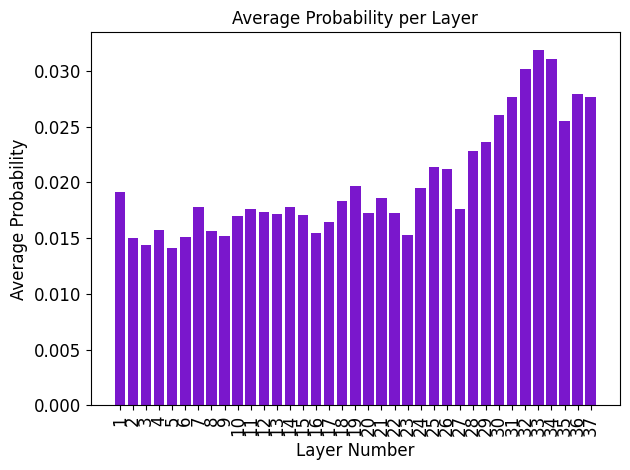

In [13]:
import matplotlib.pyplot as plt
import numpy as np
FONT_SIZE = 12
BAR_COLOR = '#7a17cc'
avg_probs = np.mean(np.stack(df['PROB'].values), axis=0)
layers = np.arange(1, len(avg_probs) + 1)
plt.bar(layers, avg_probs, color=BAR_COLOR)
plt.xlabel('Layer Number', fontsize=FONT_SIZE)
plt.ylabel('Average Probability', fontsize=FONT_SIZE)
plt.title('Average Probability per Layer', fontsize=FONT_SIZE)
plt.xticks(layers, fontsize=FONT_SIZE, rotation=90)
plt.yticks(fontsize=FONT_SIZE)
plt.ylim(0, max(avg_probs) * 1.05)
plt.tight_layout()
plt.savefig('layer_avg_probs.png')

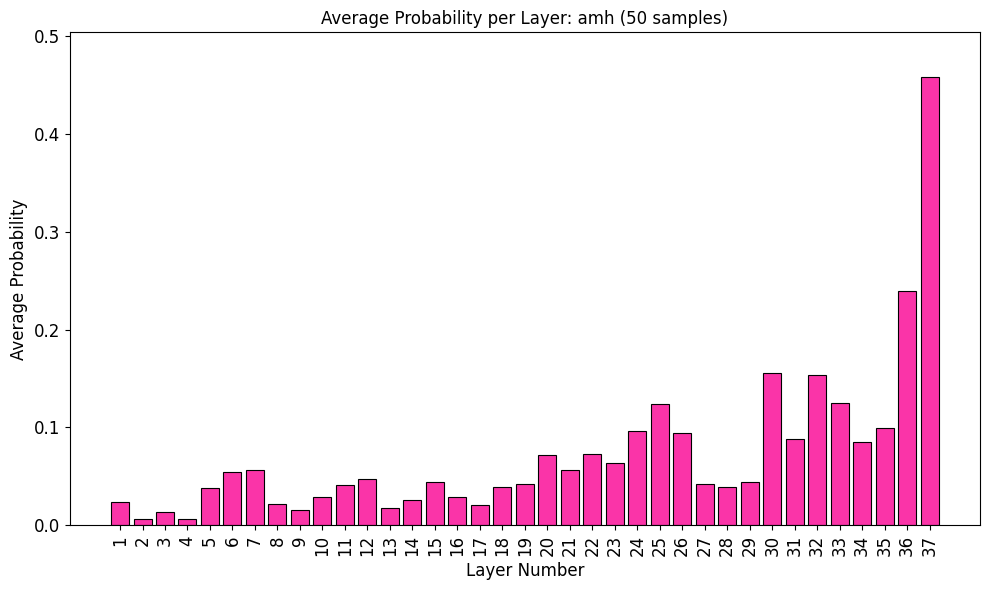

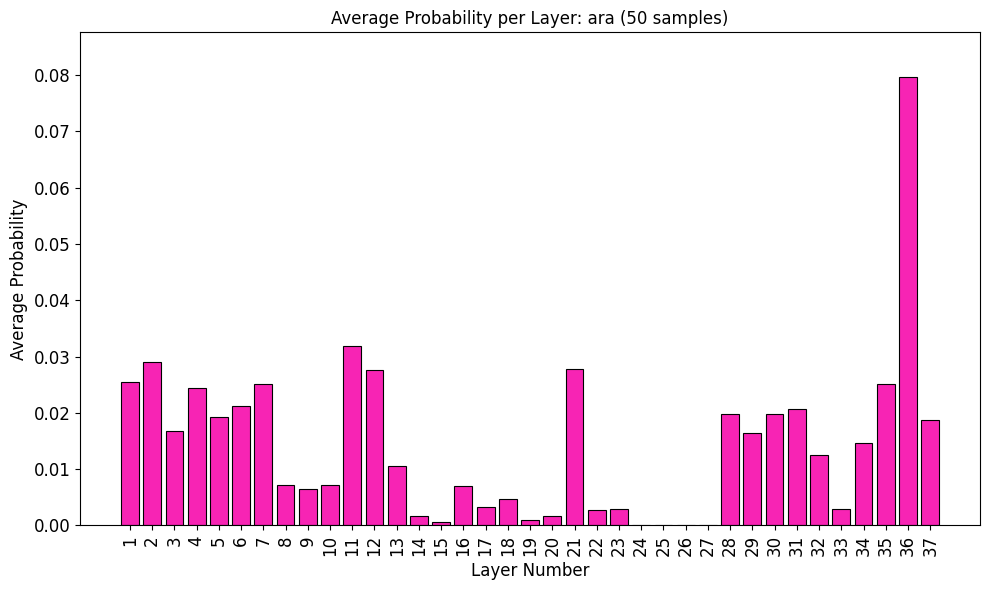

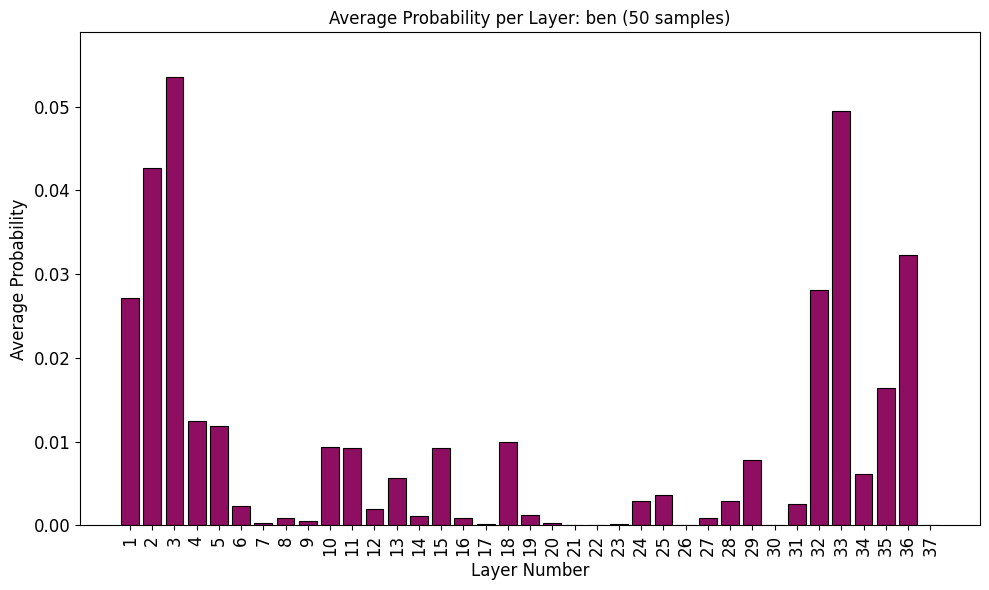

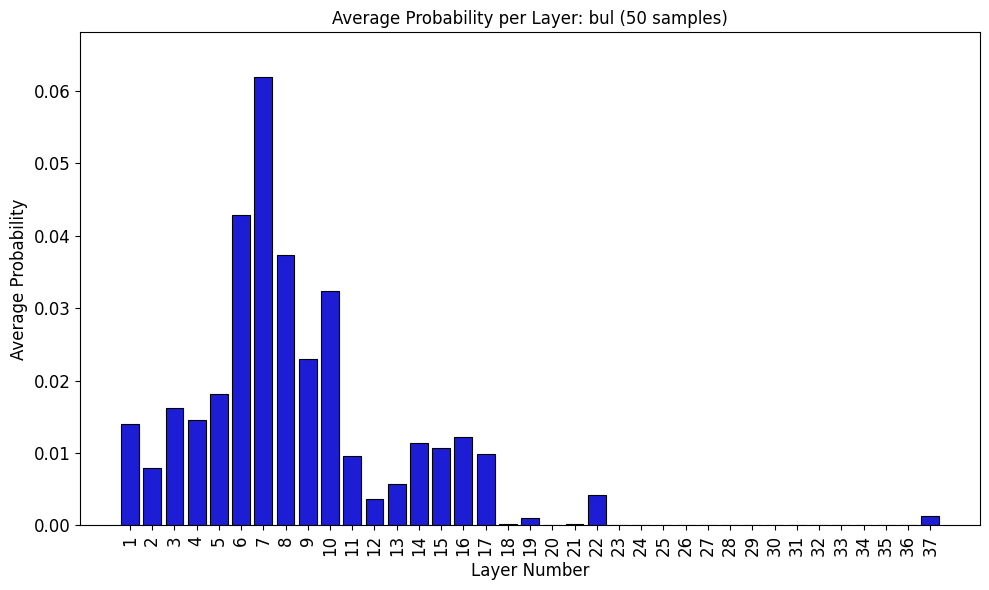

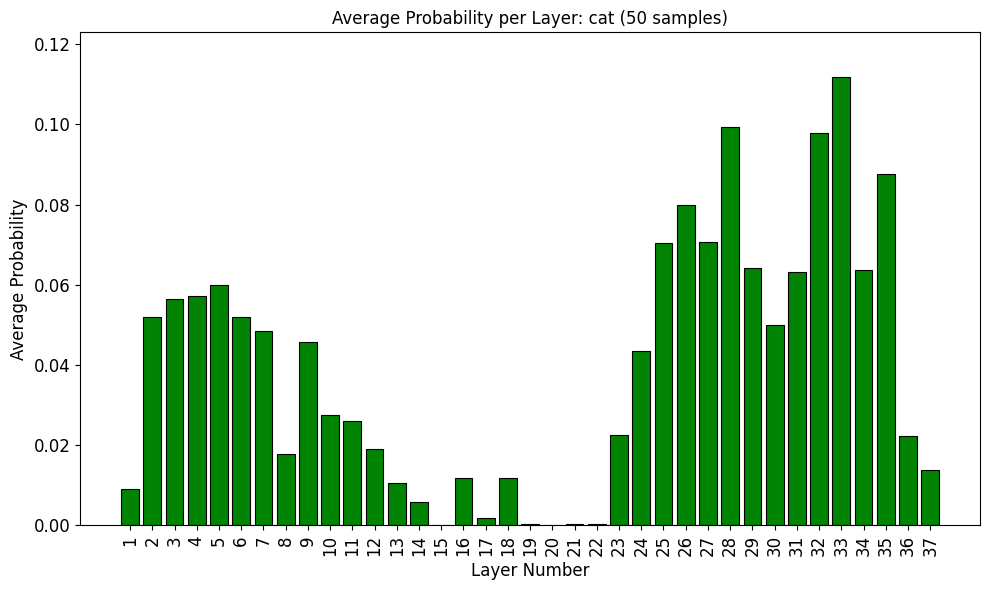

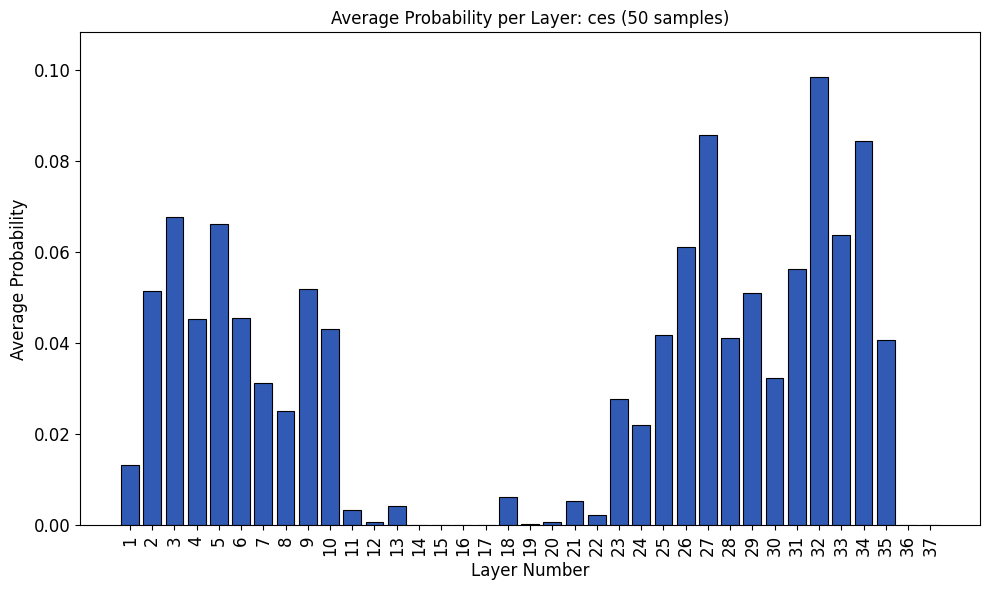

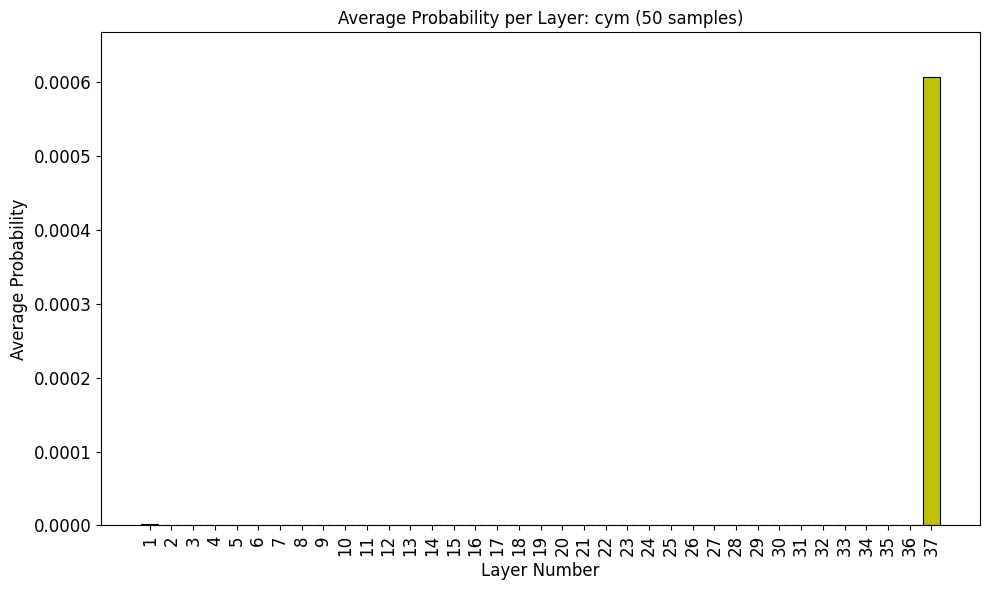

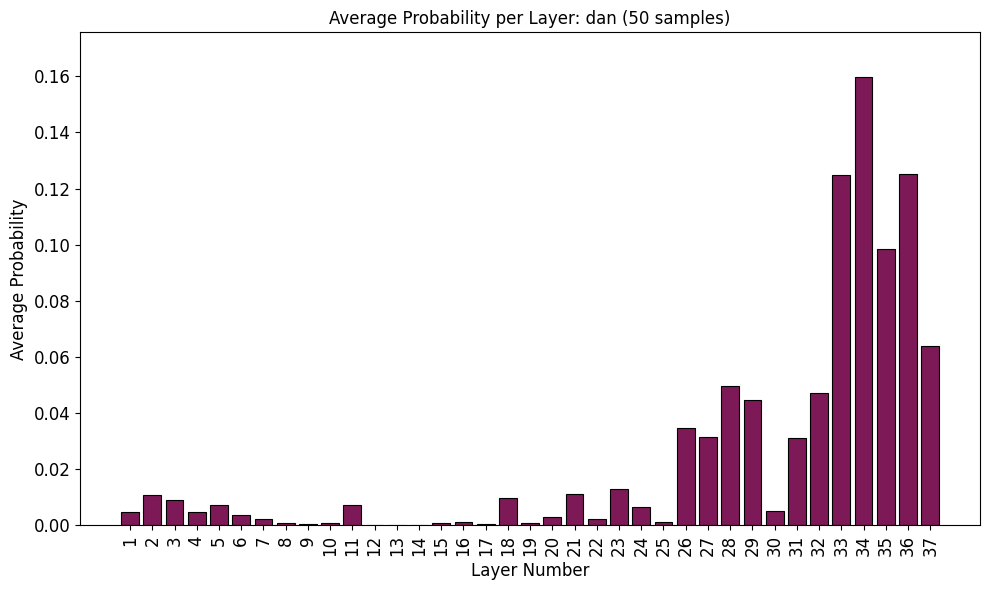

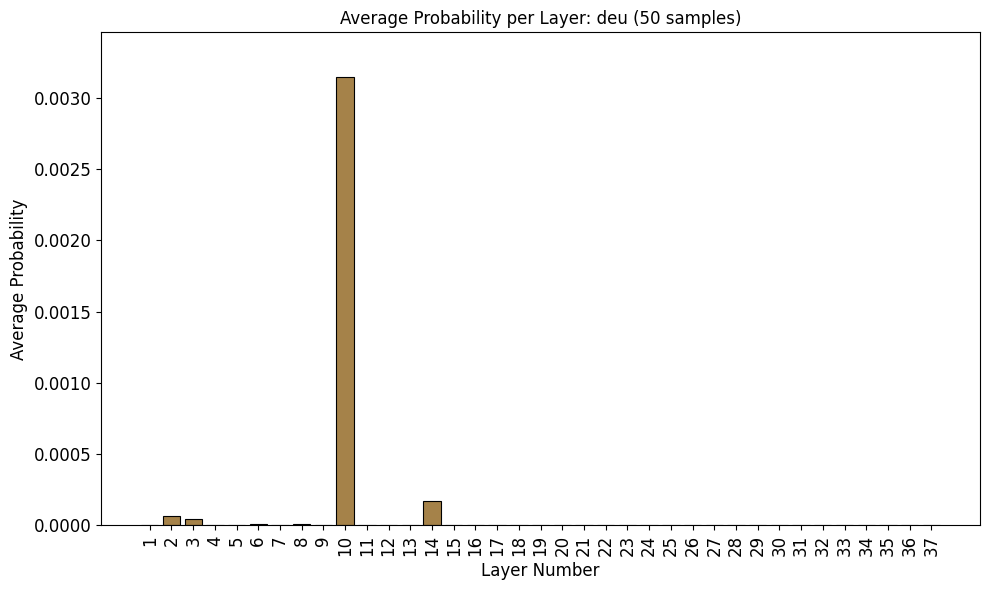

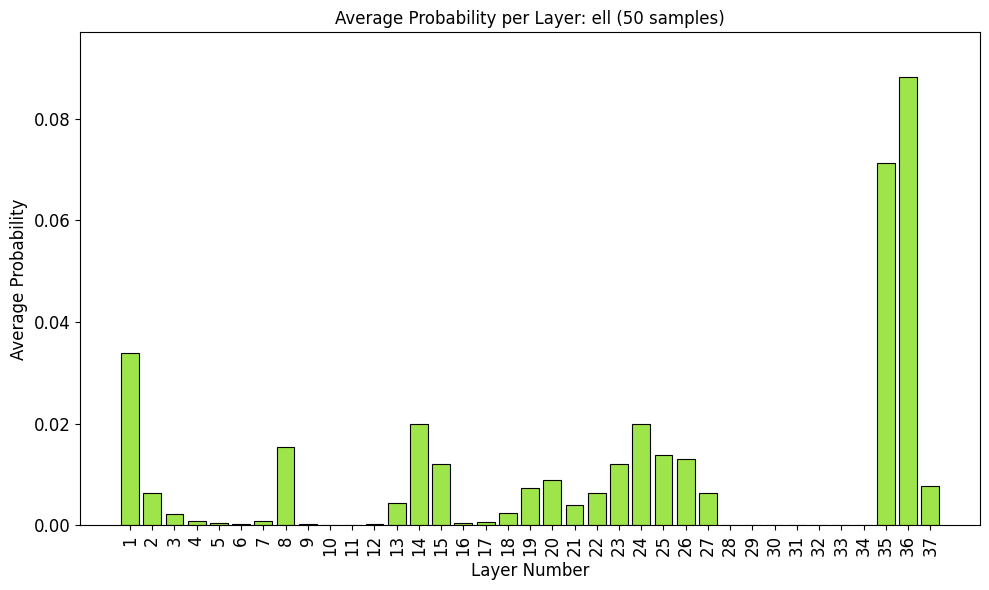

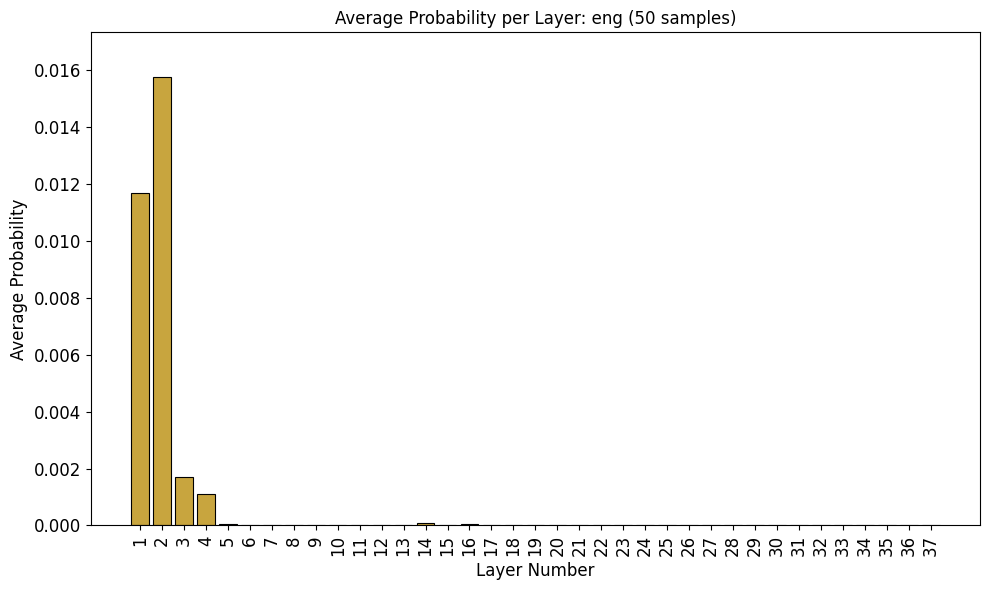

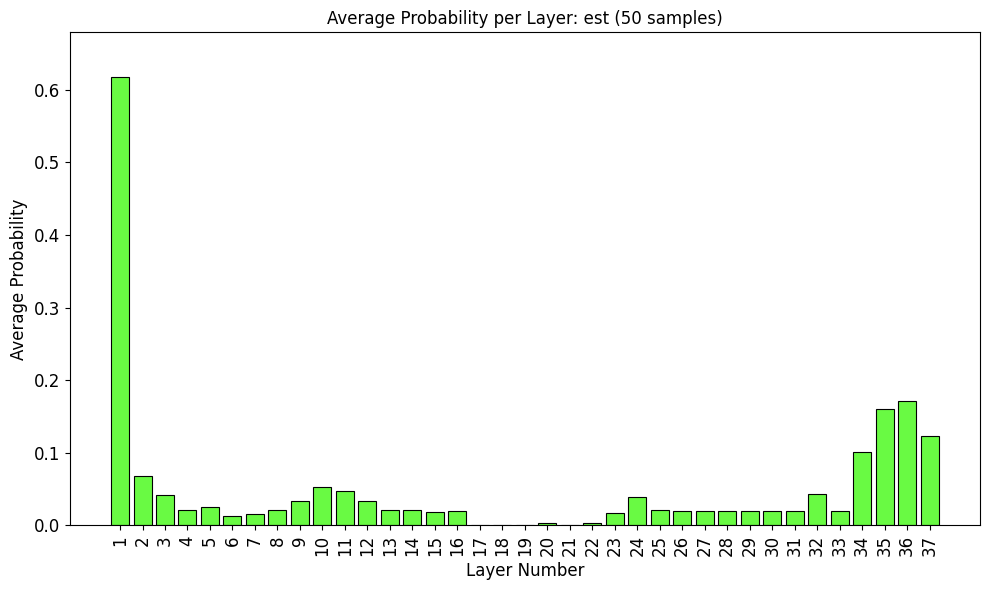

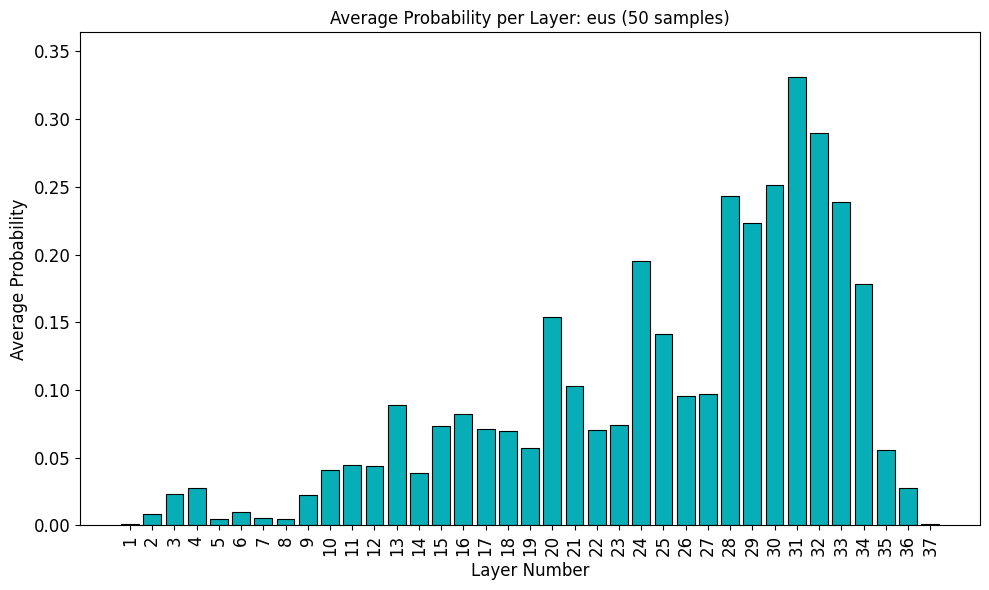

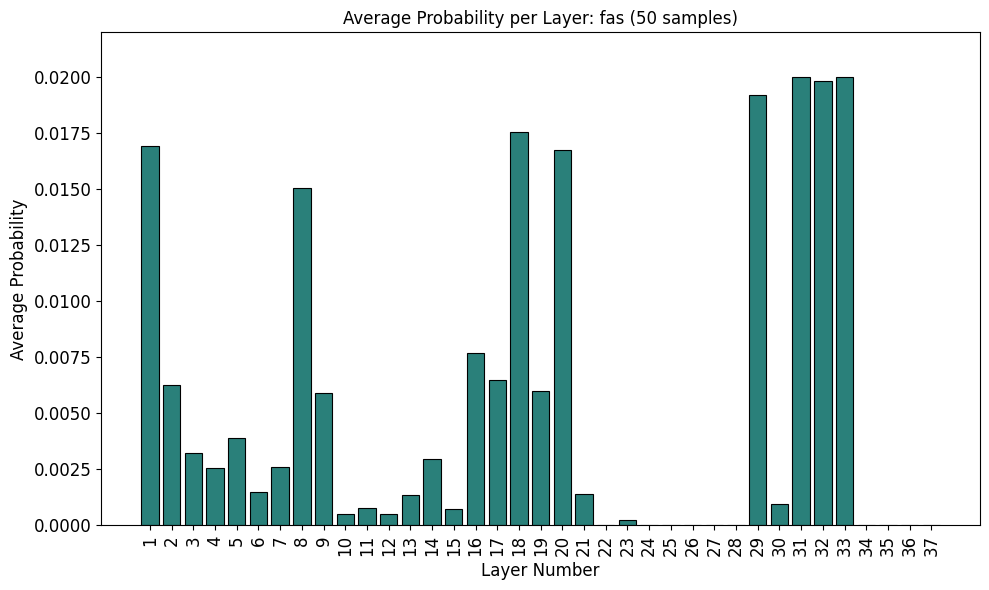

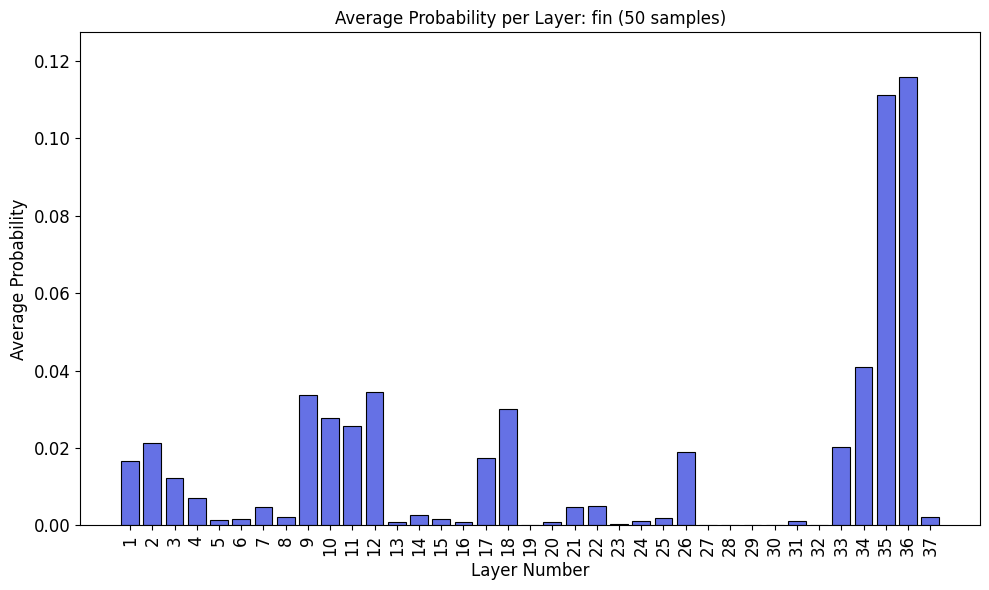

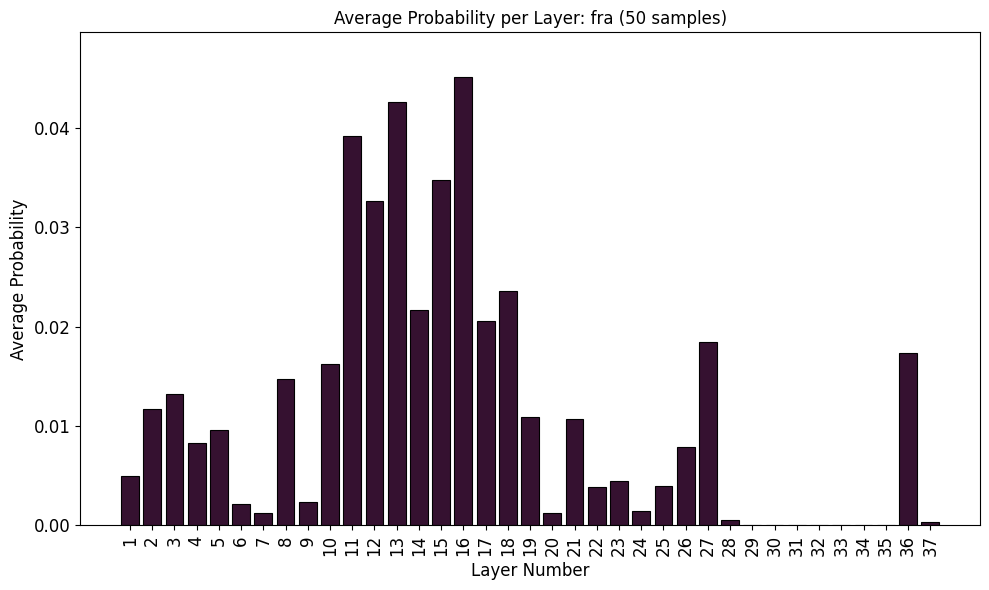

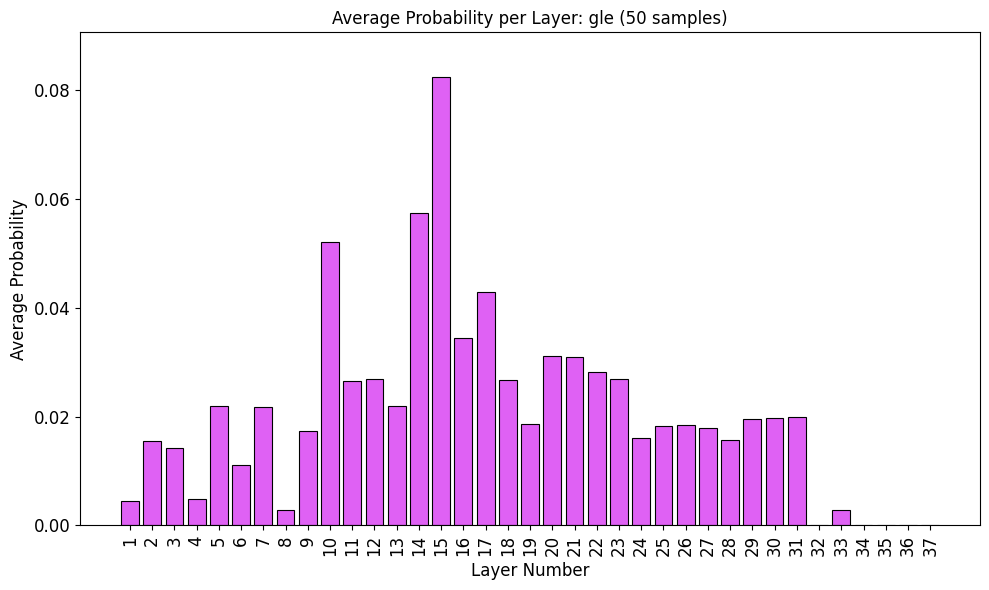

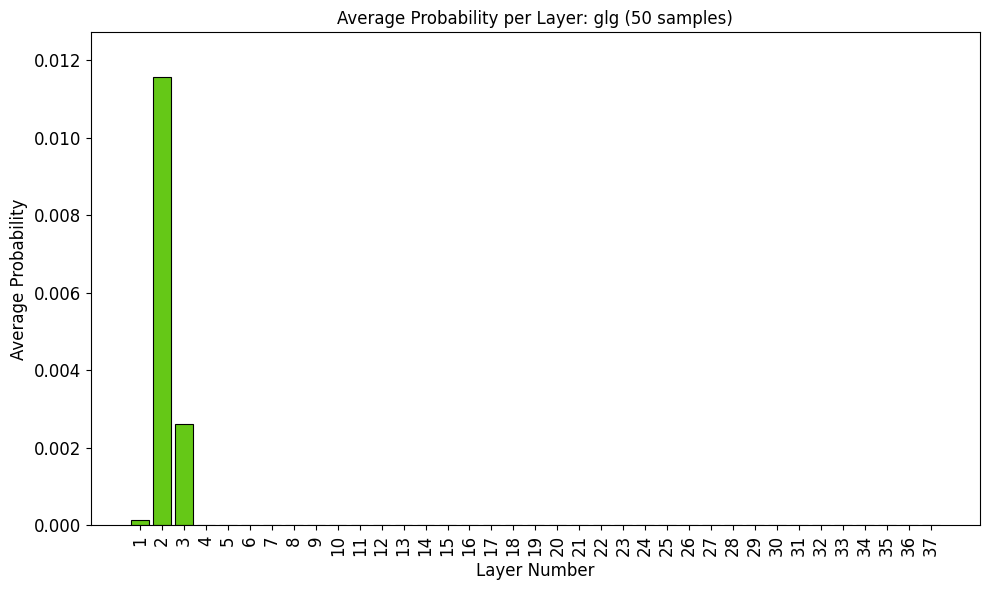

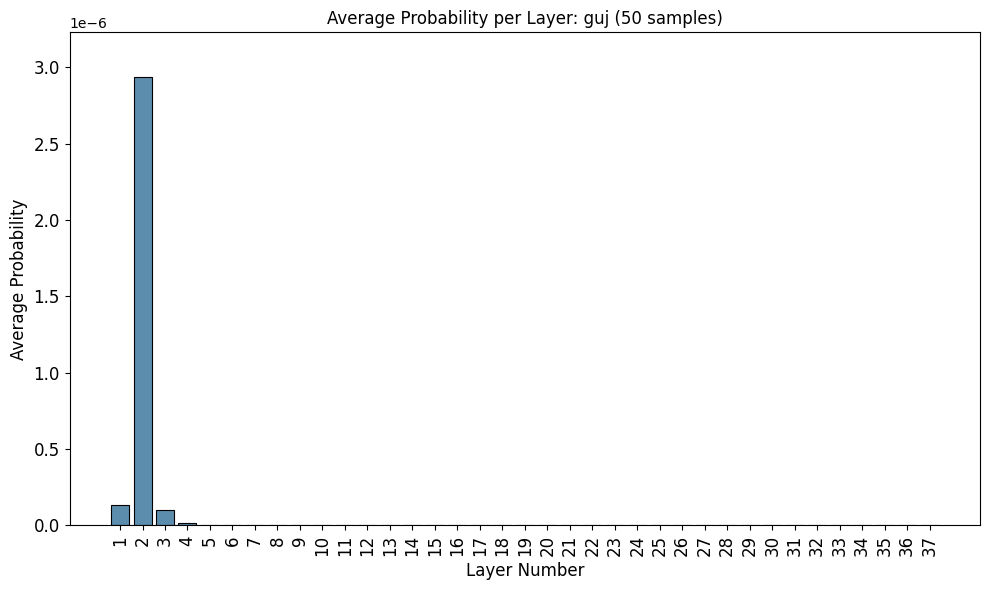

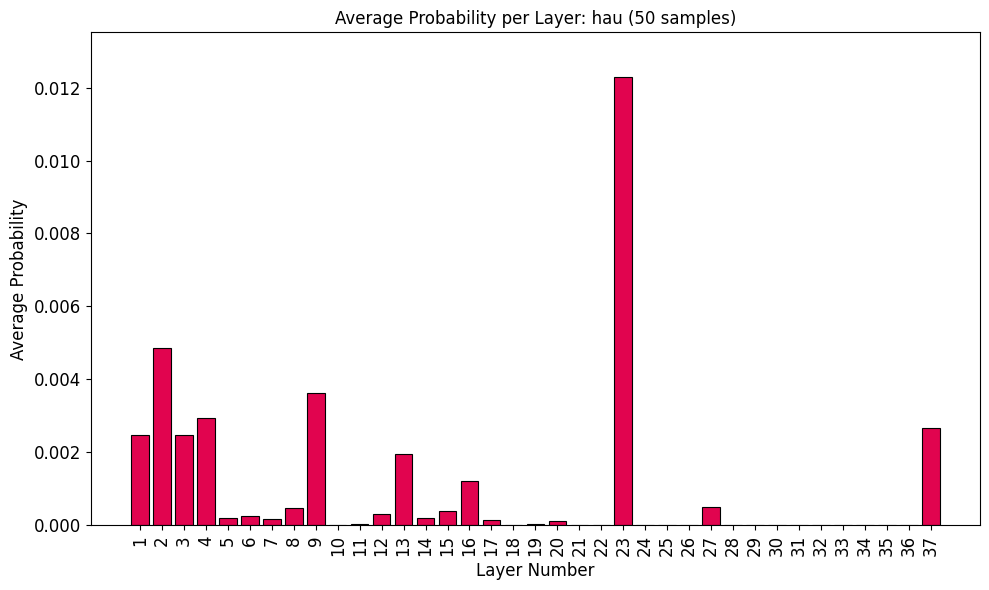

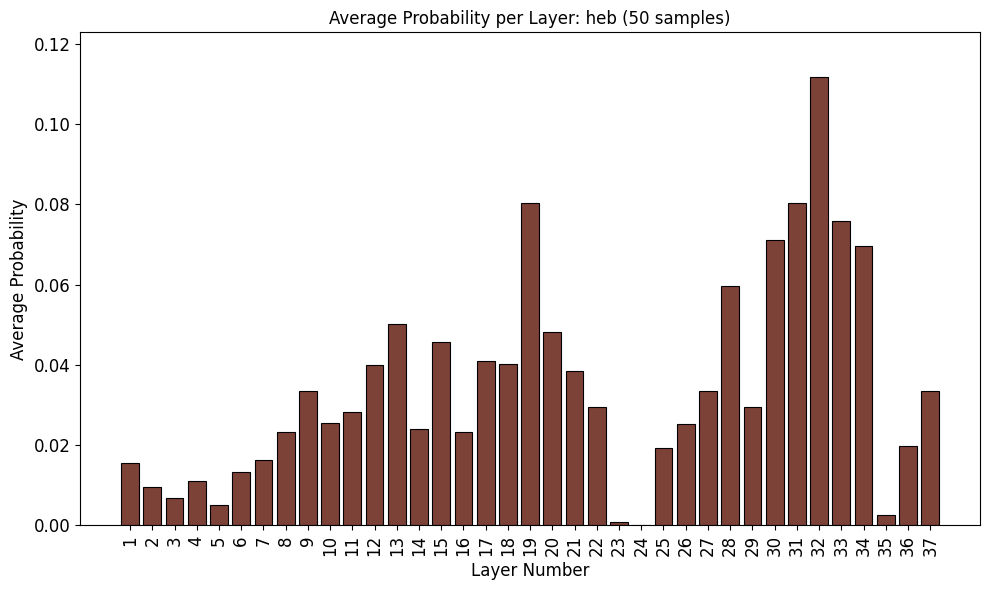

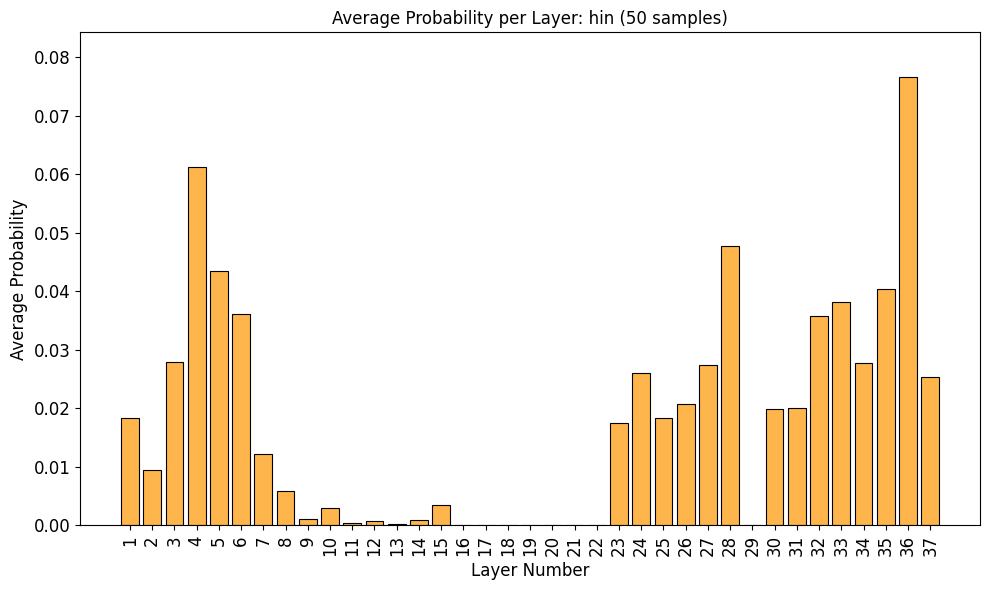

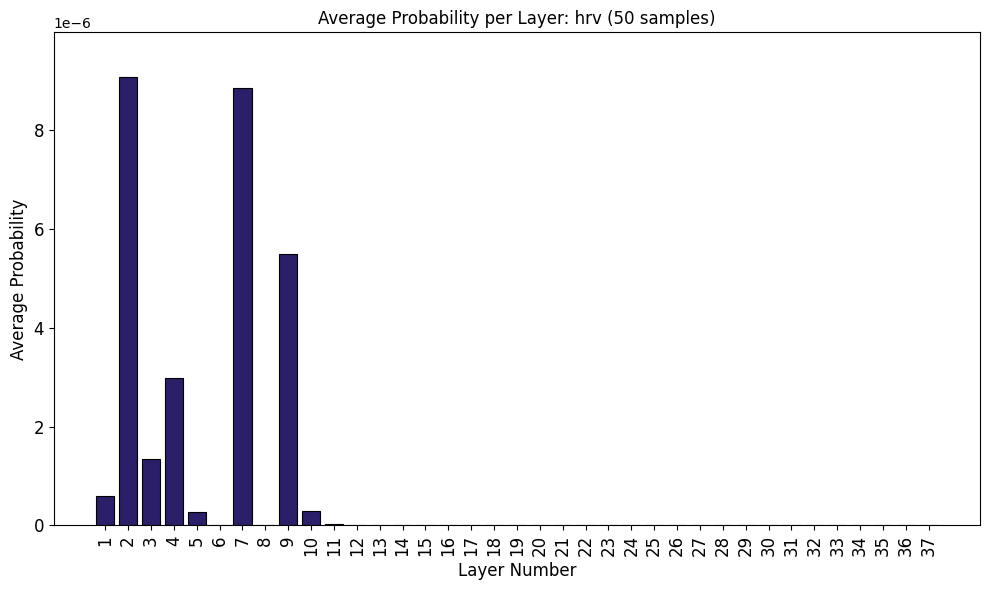

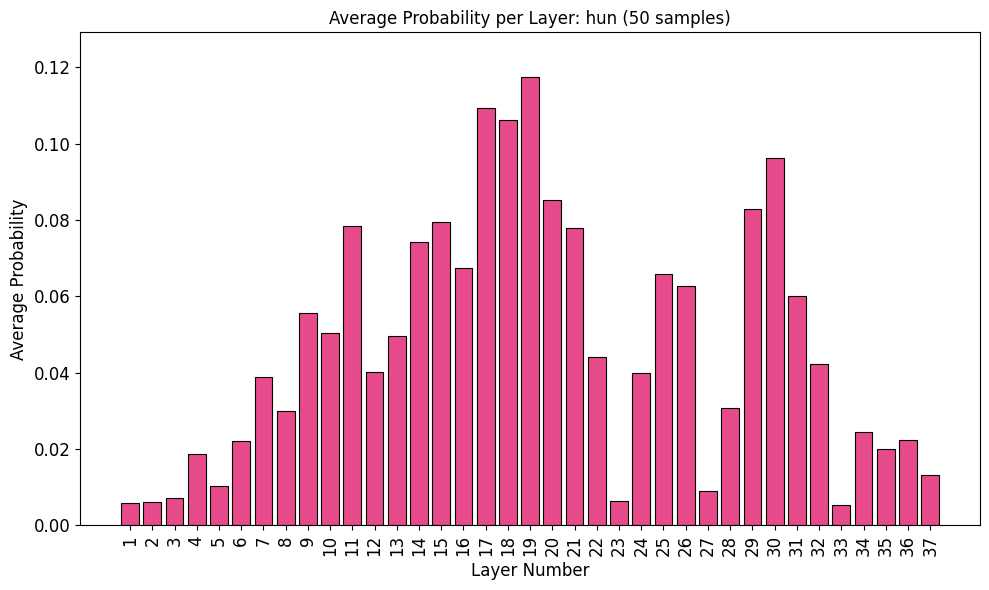

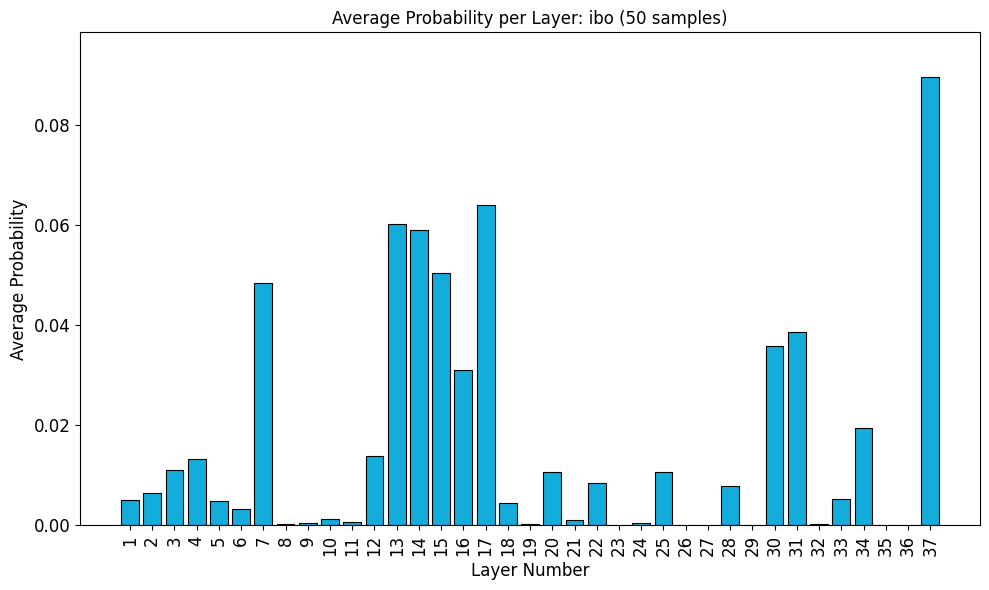

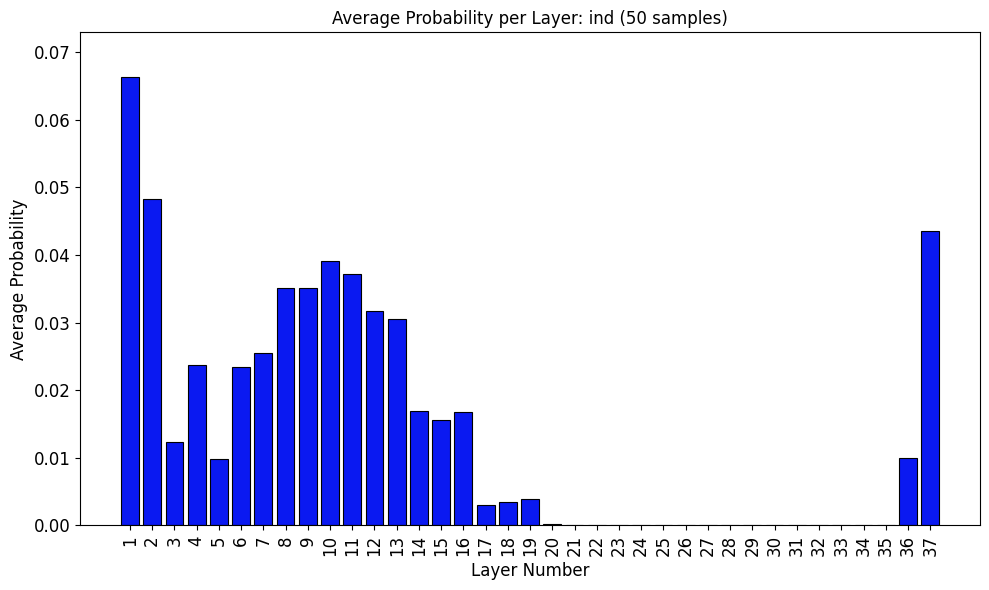

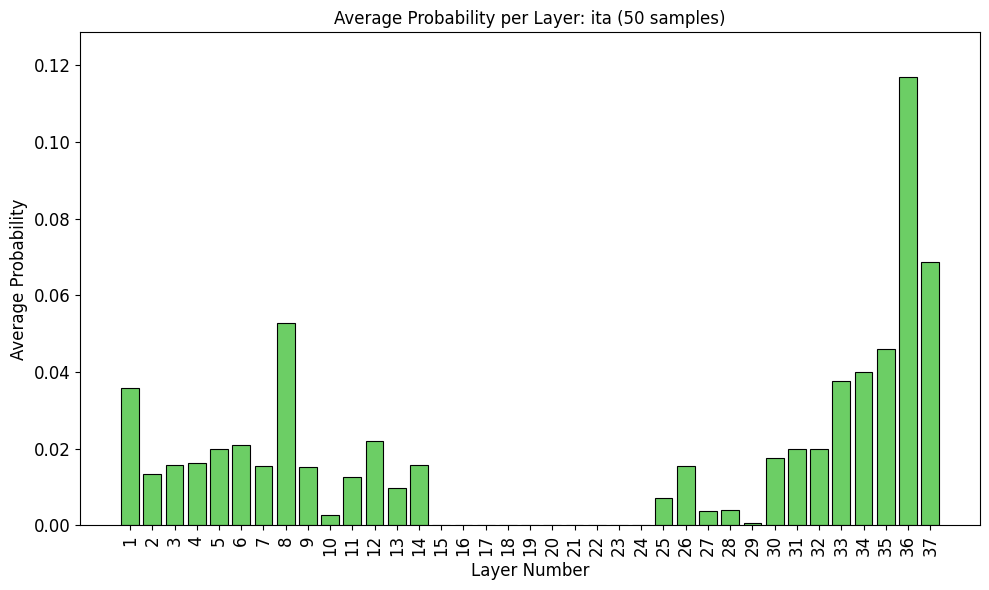

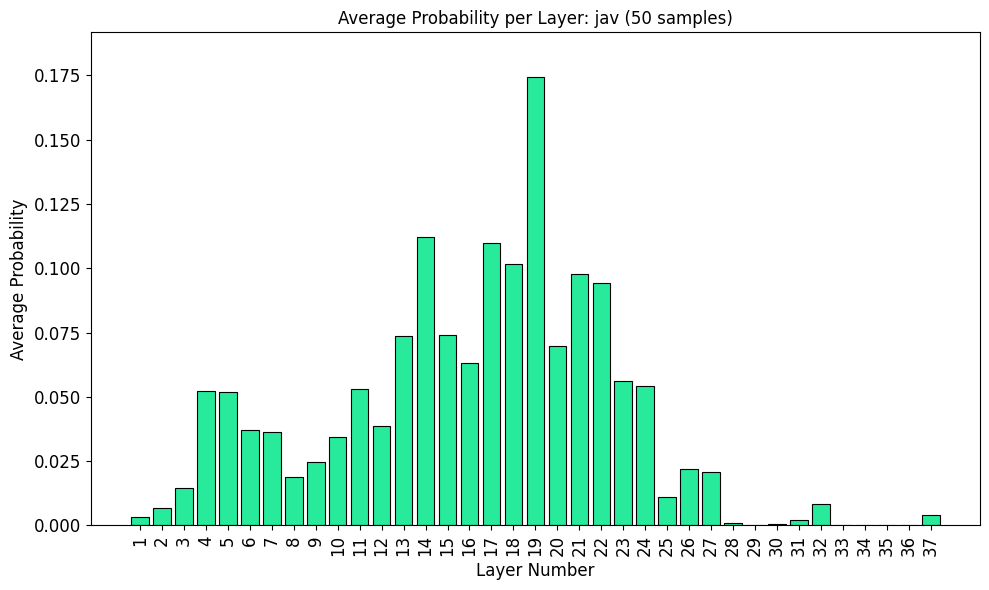

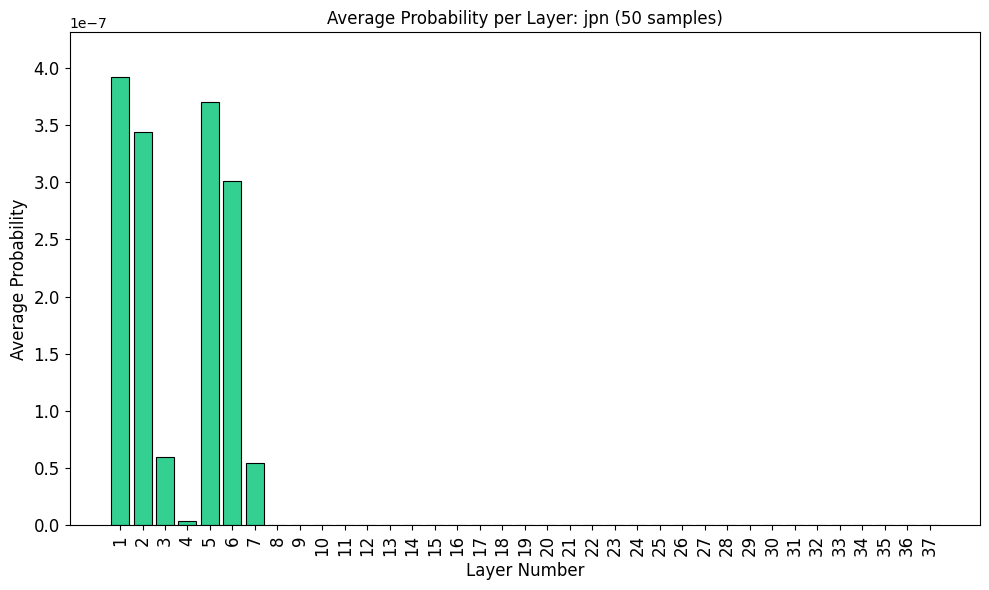

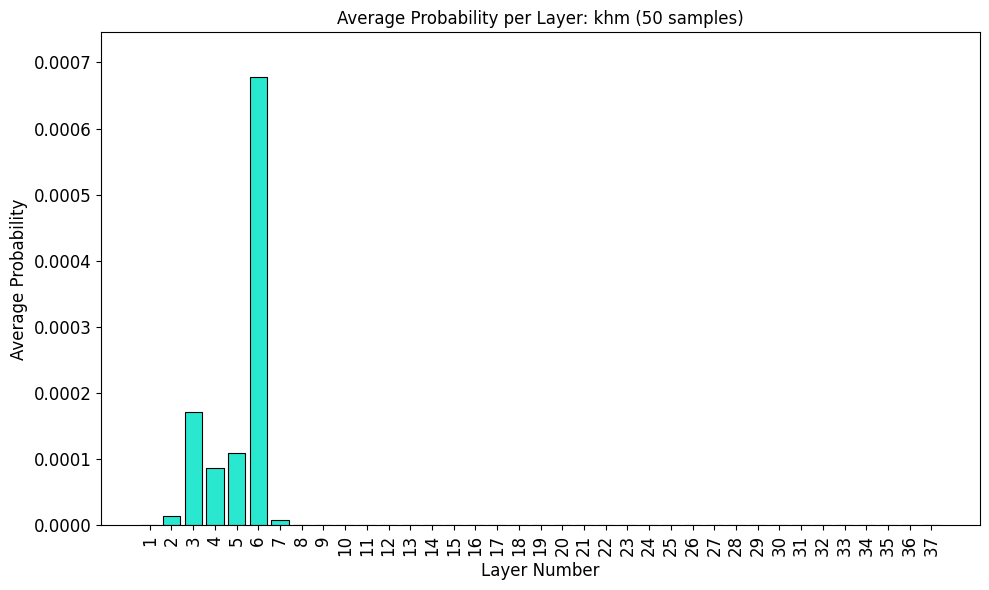

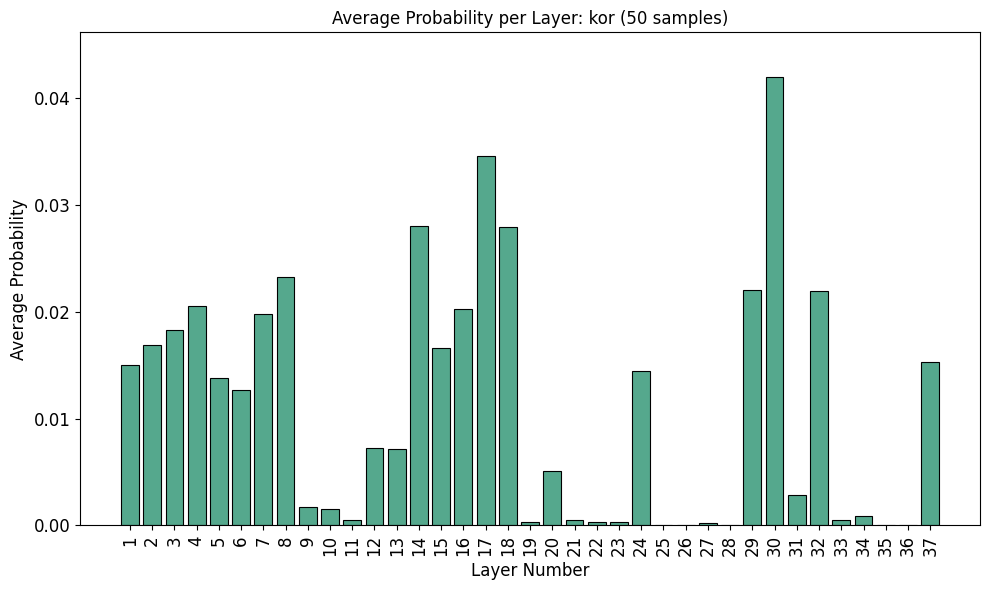

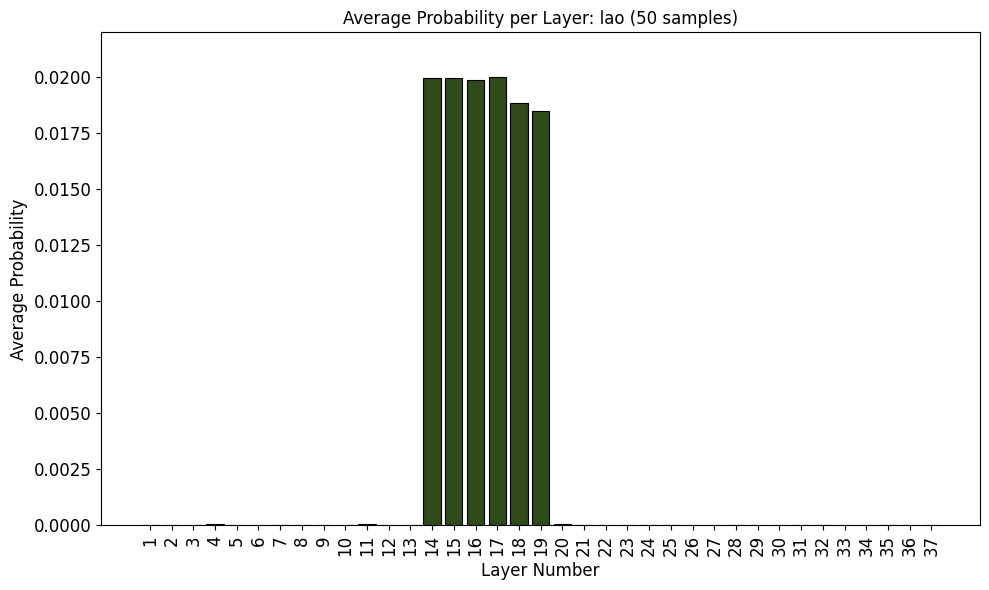

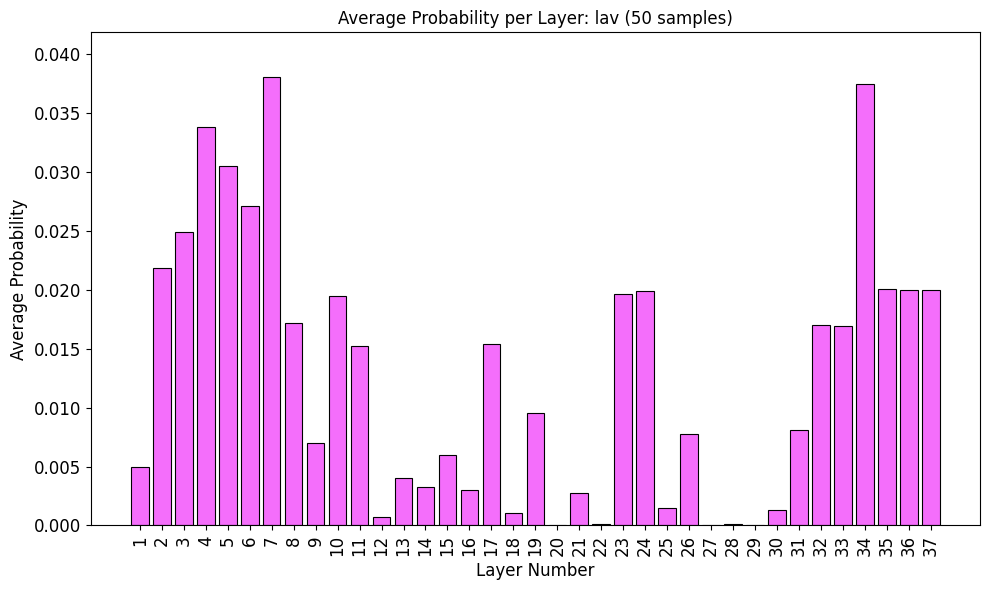

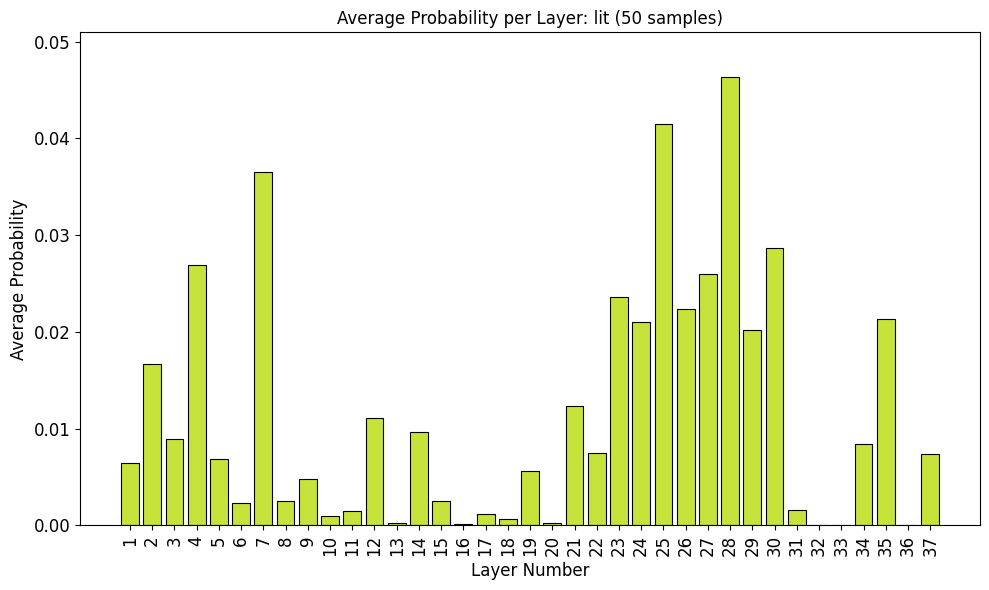

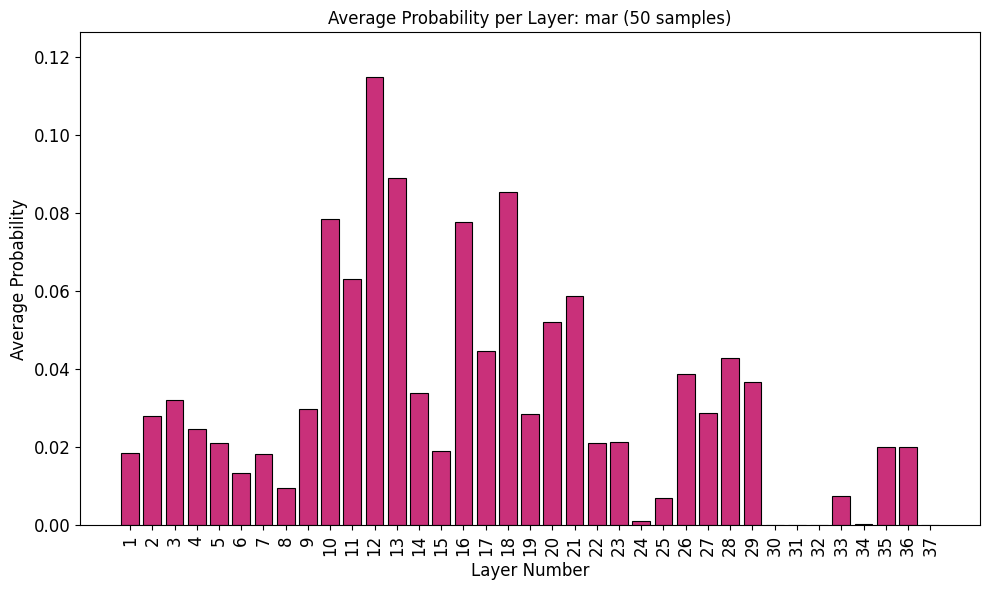

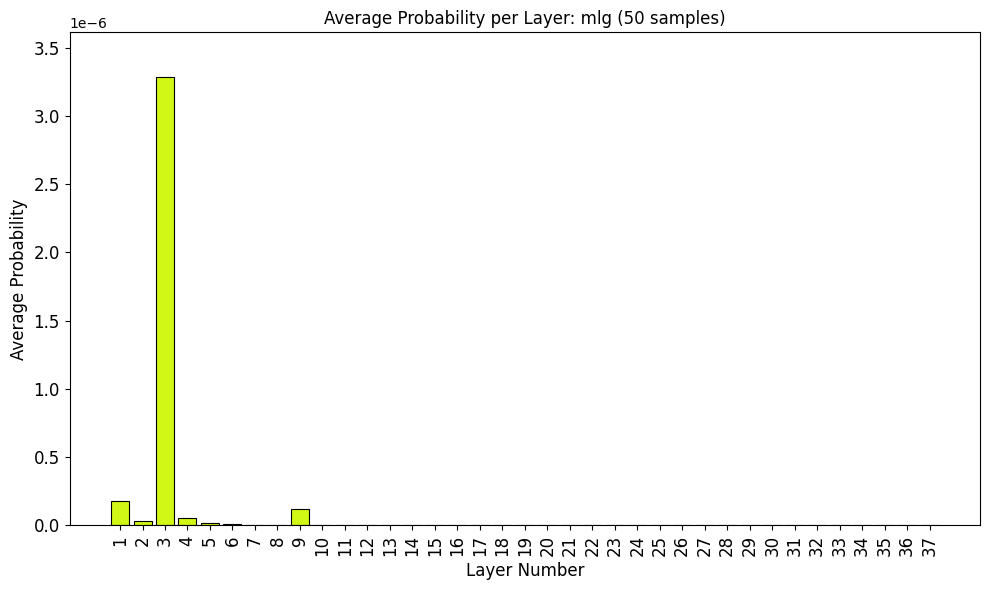

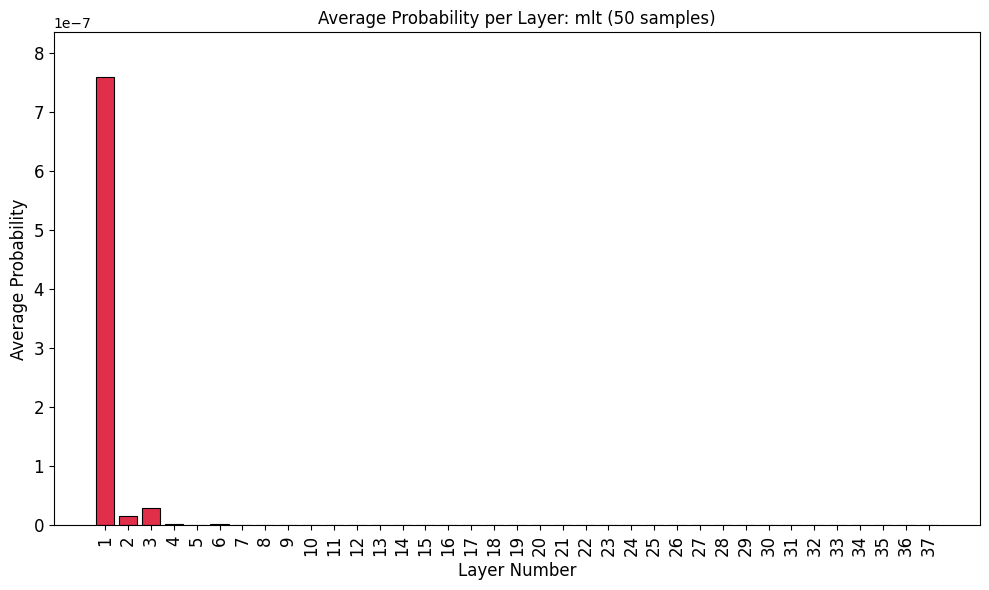

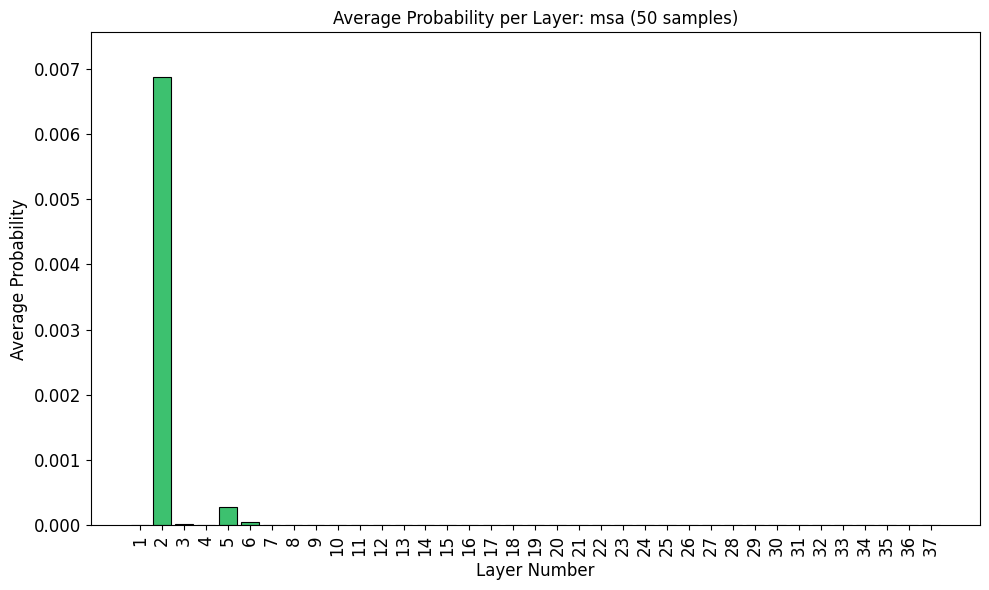

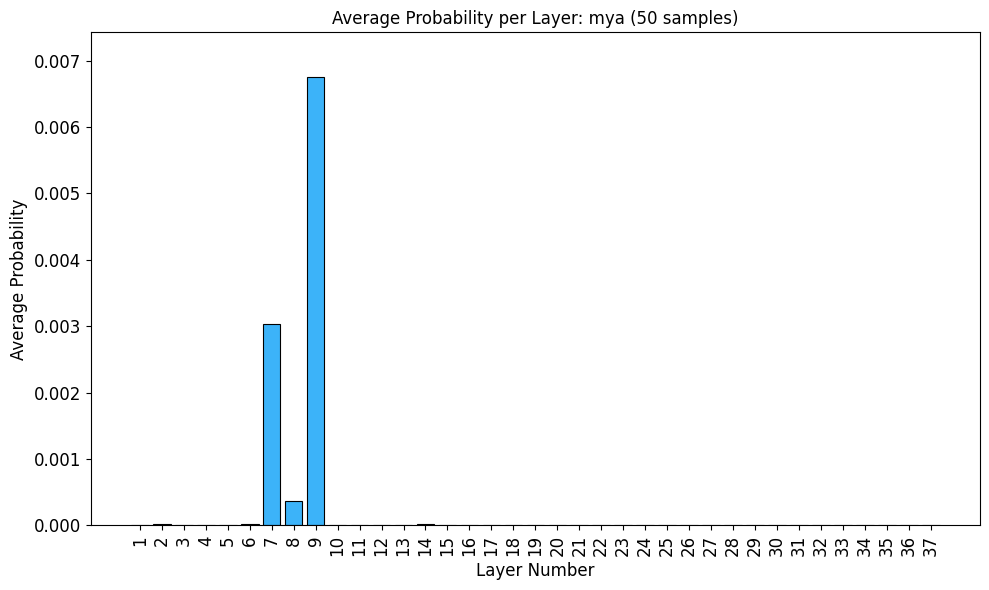

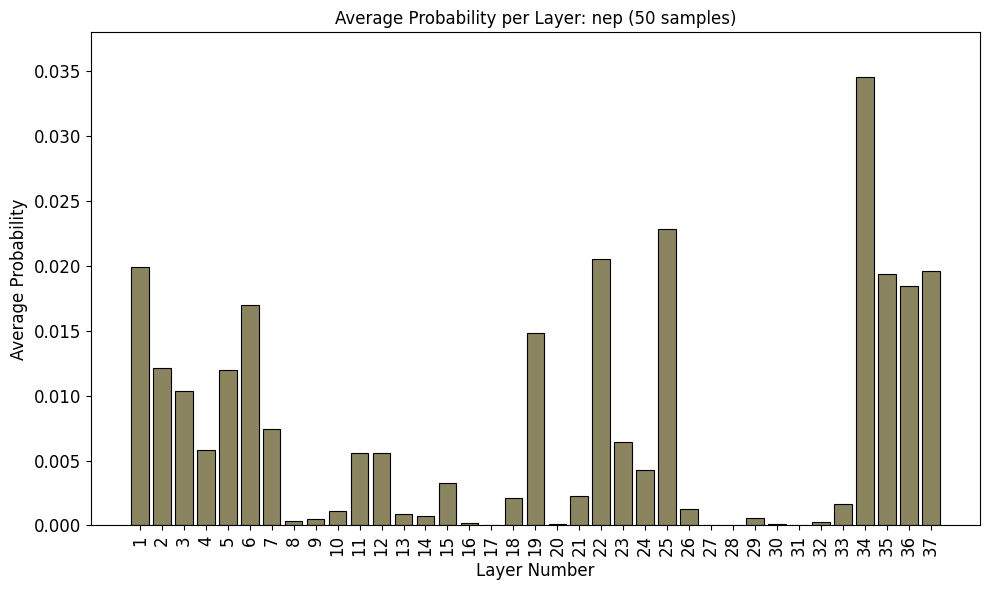

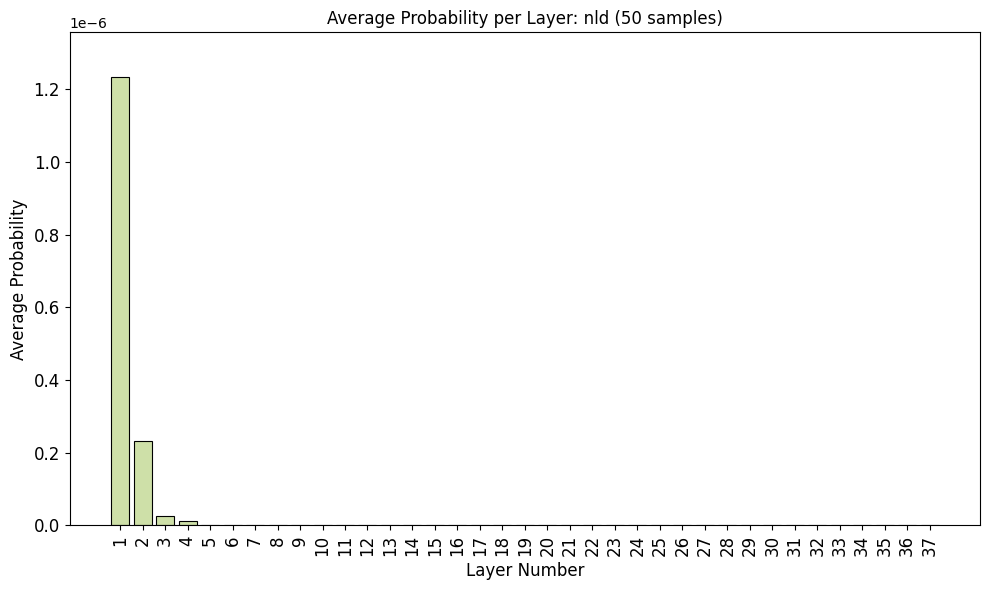

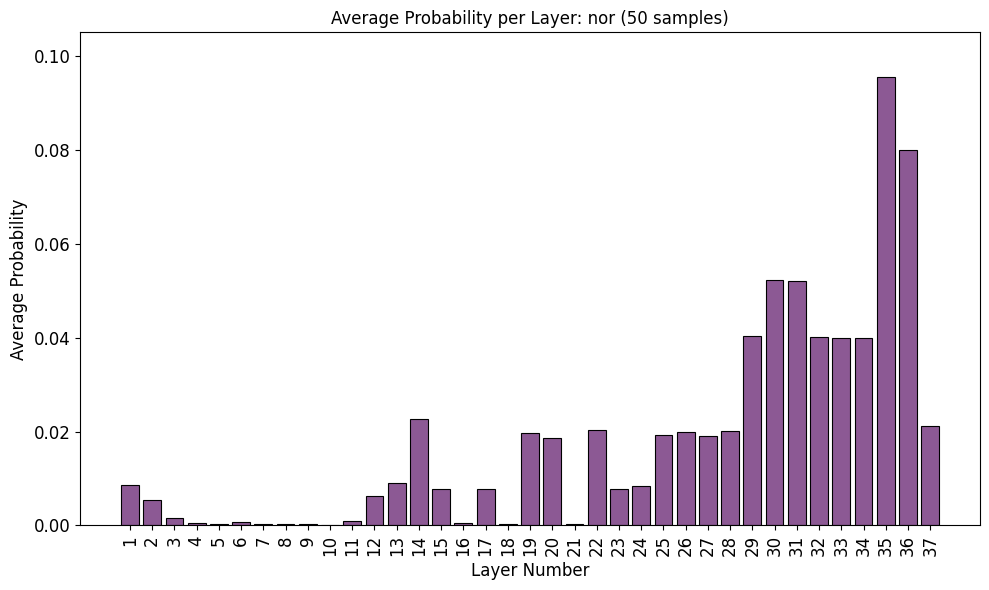

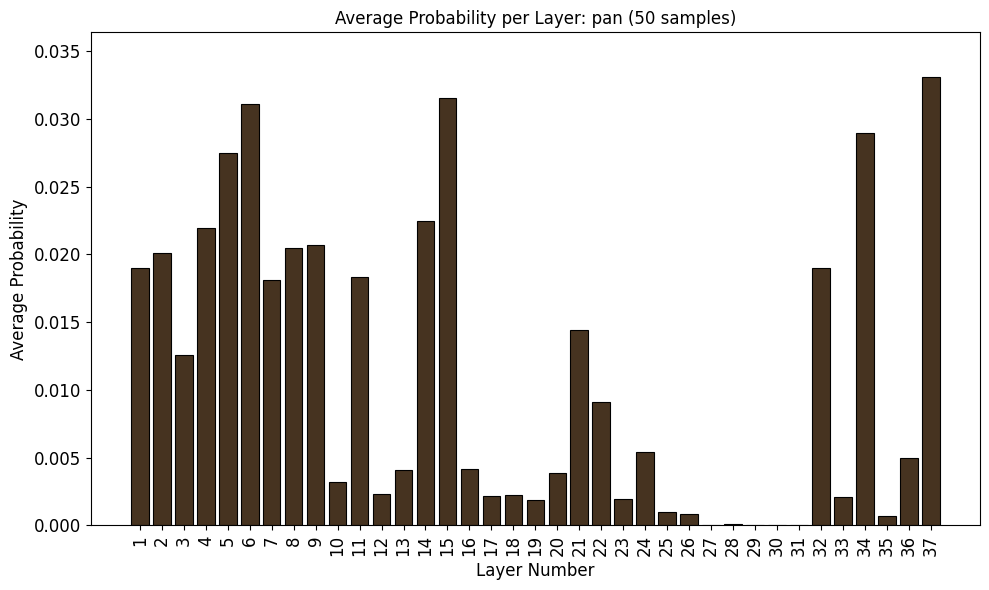

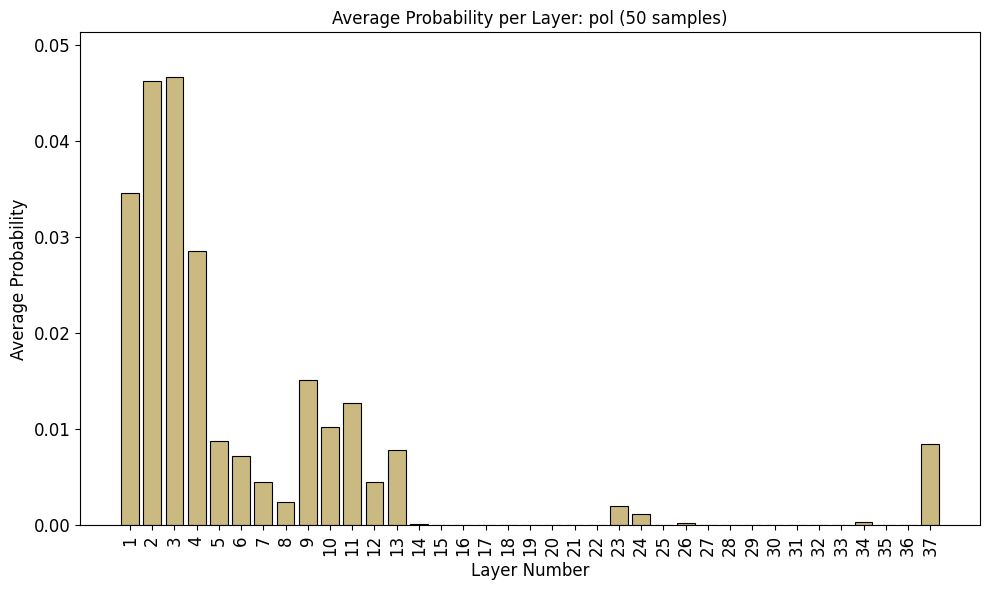

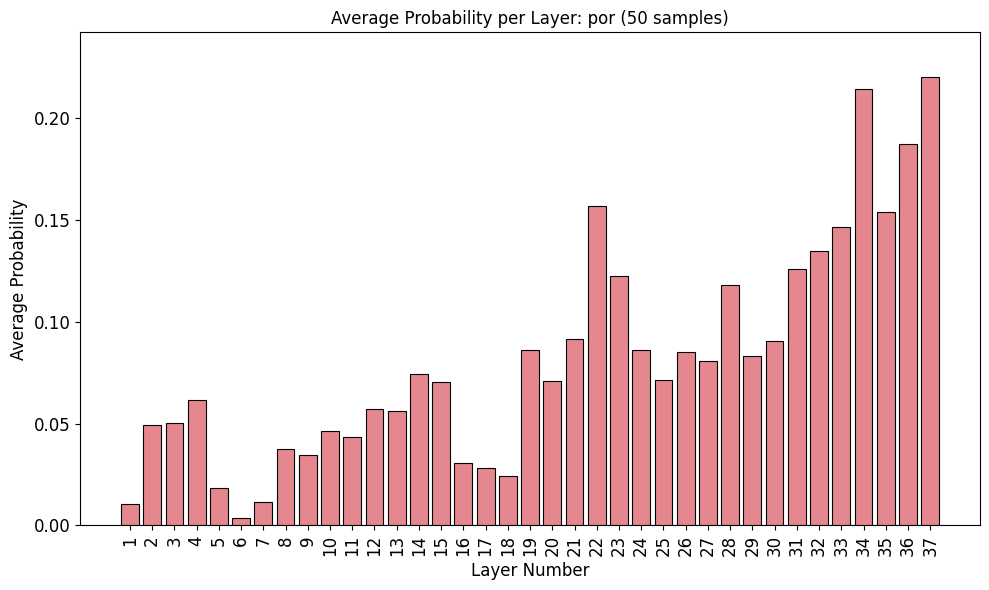

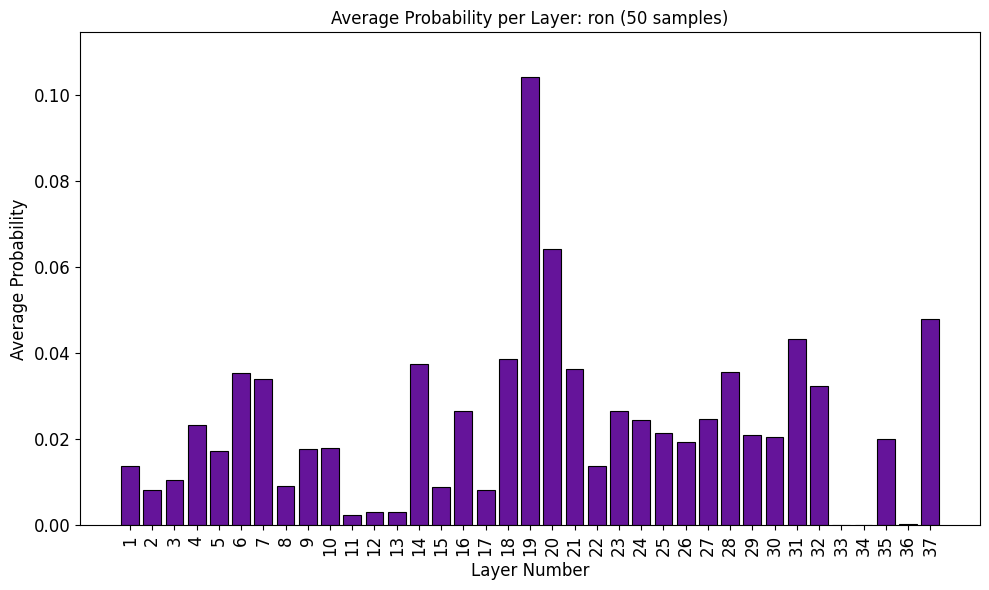

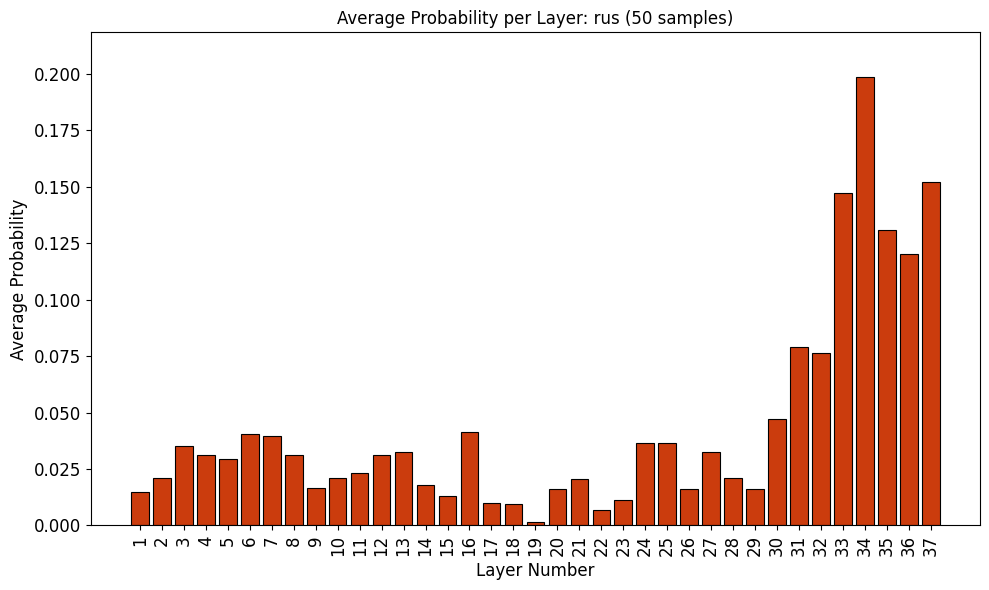

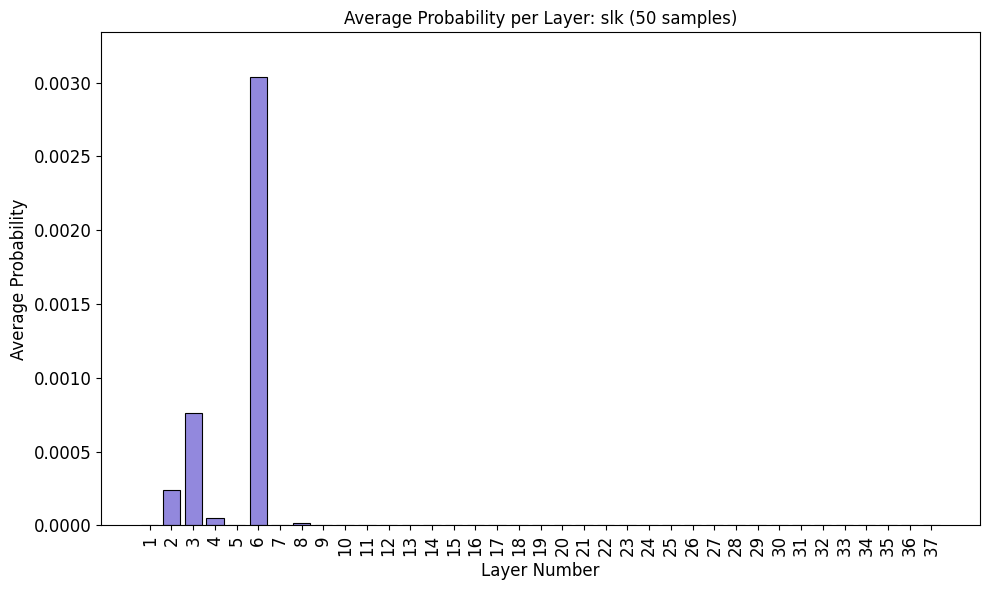

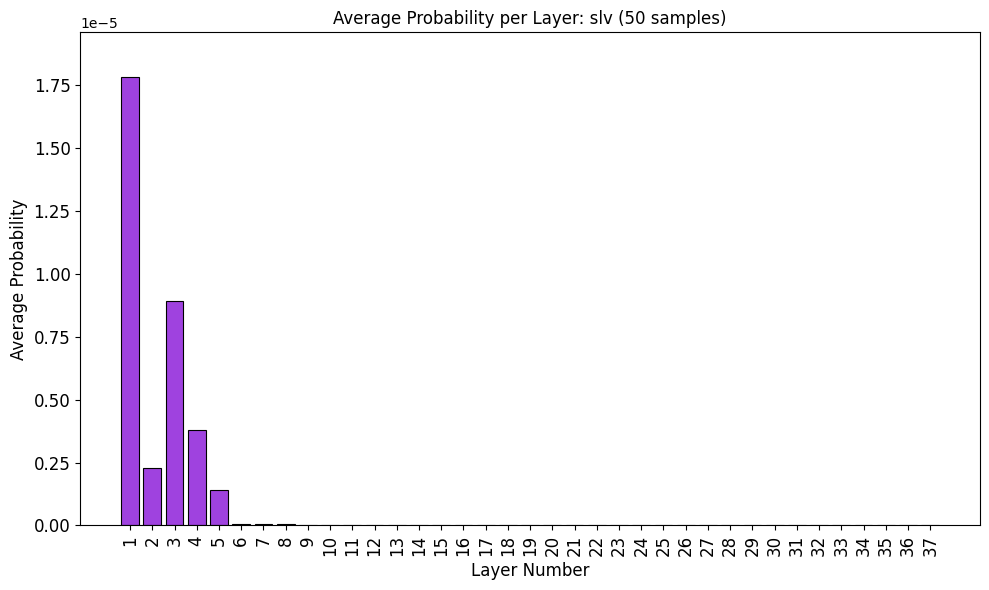

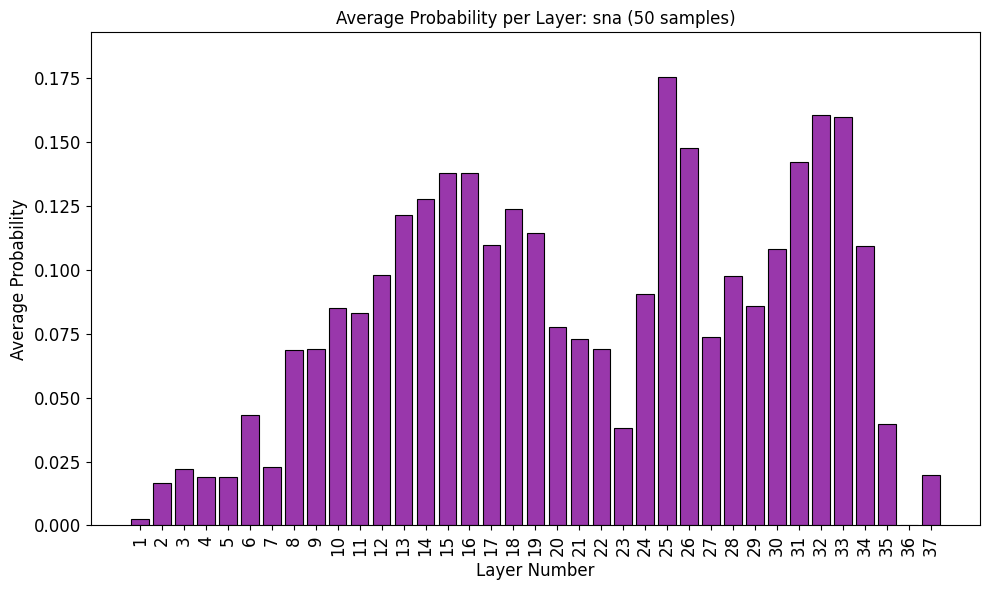

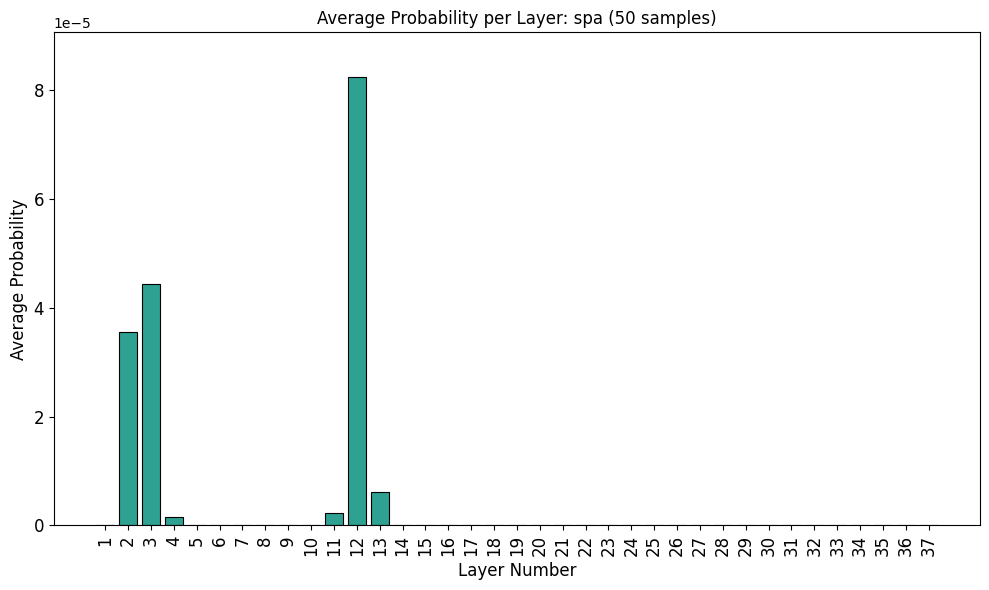

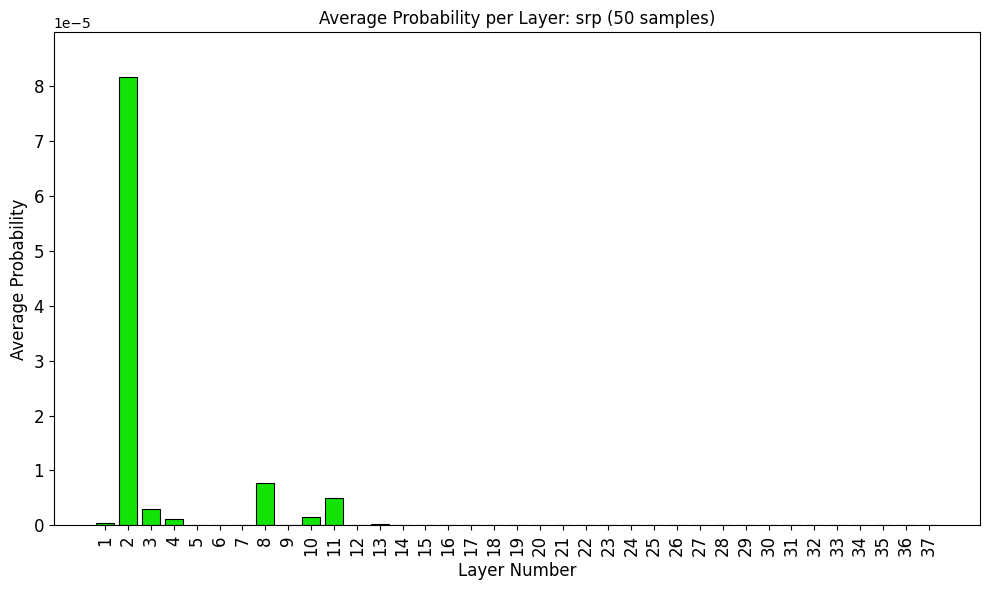

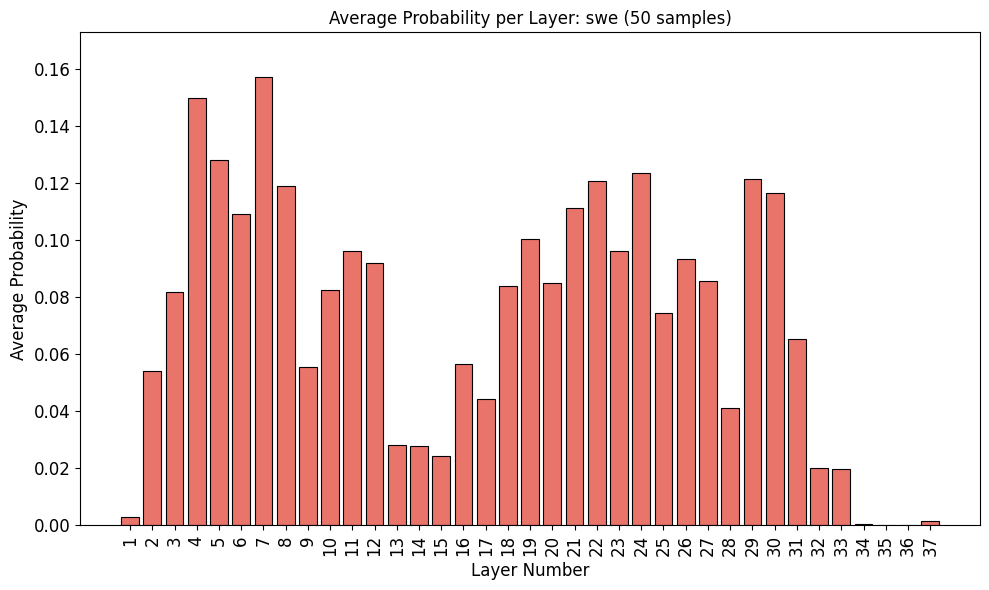

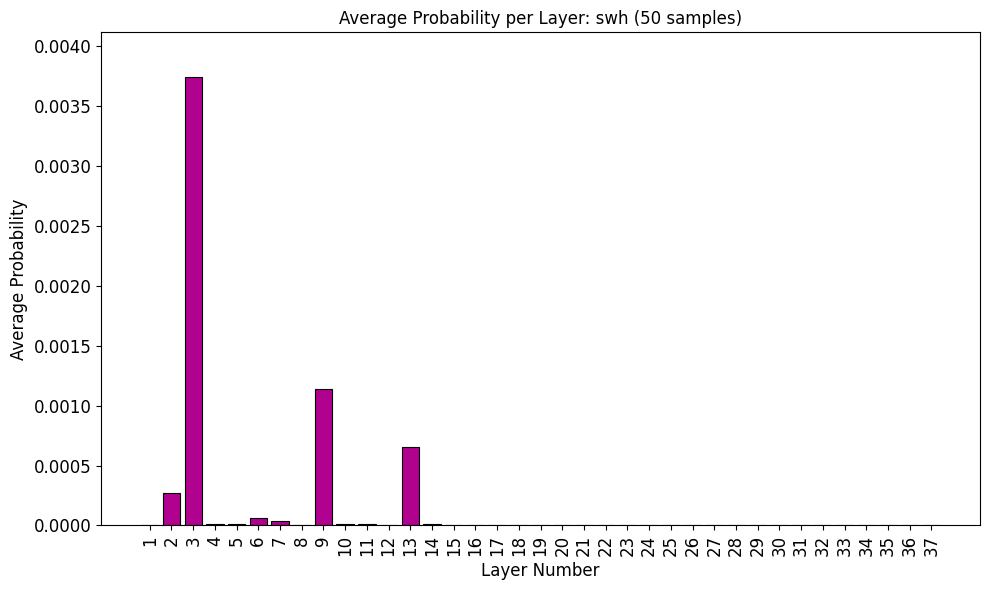

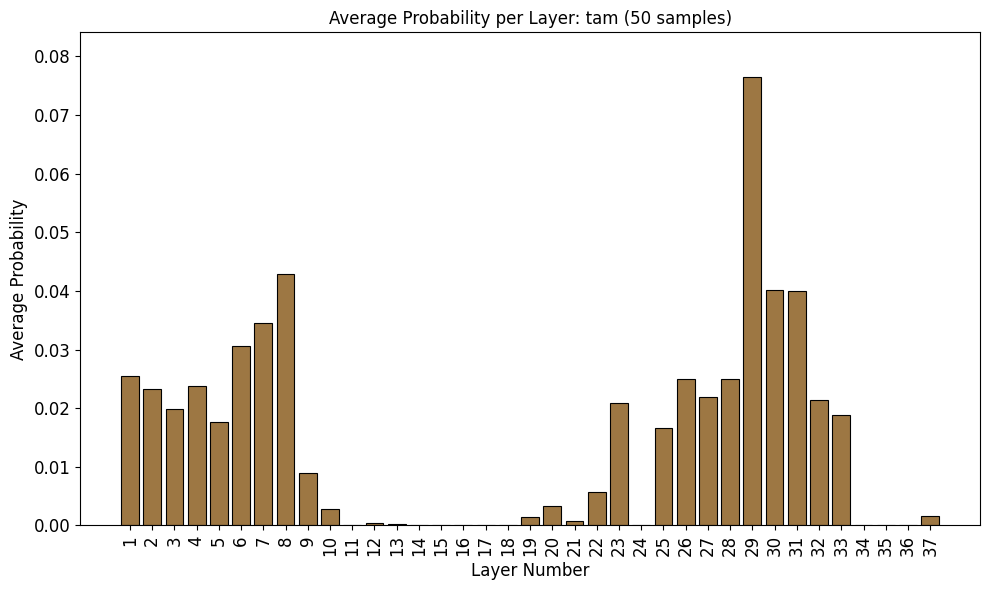

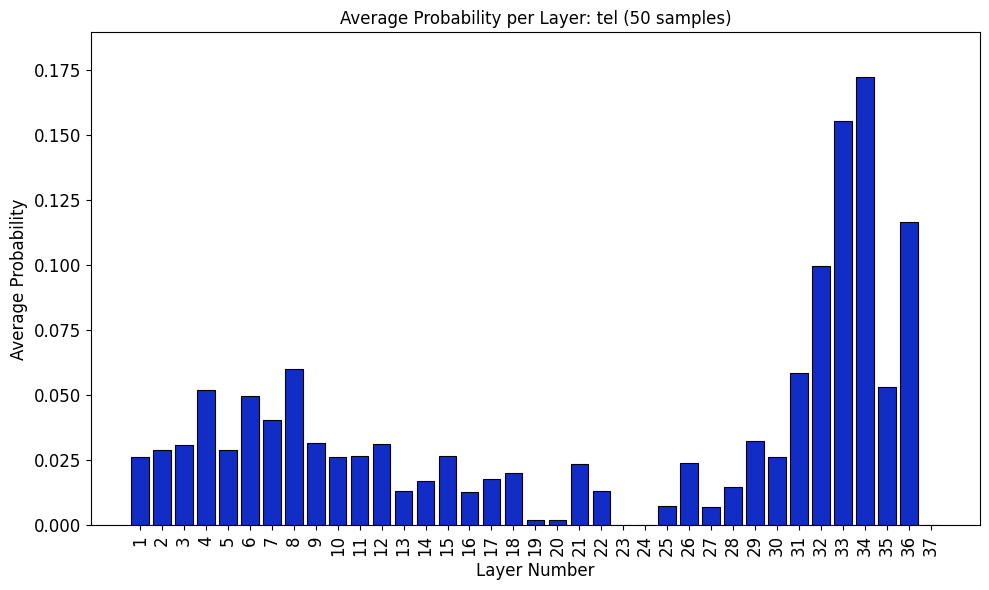

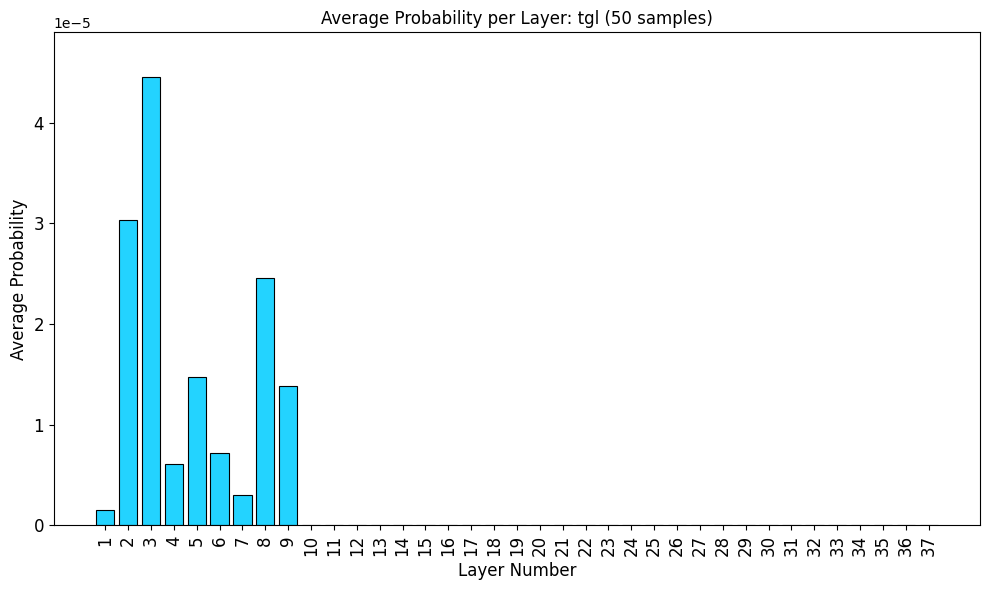

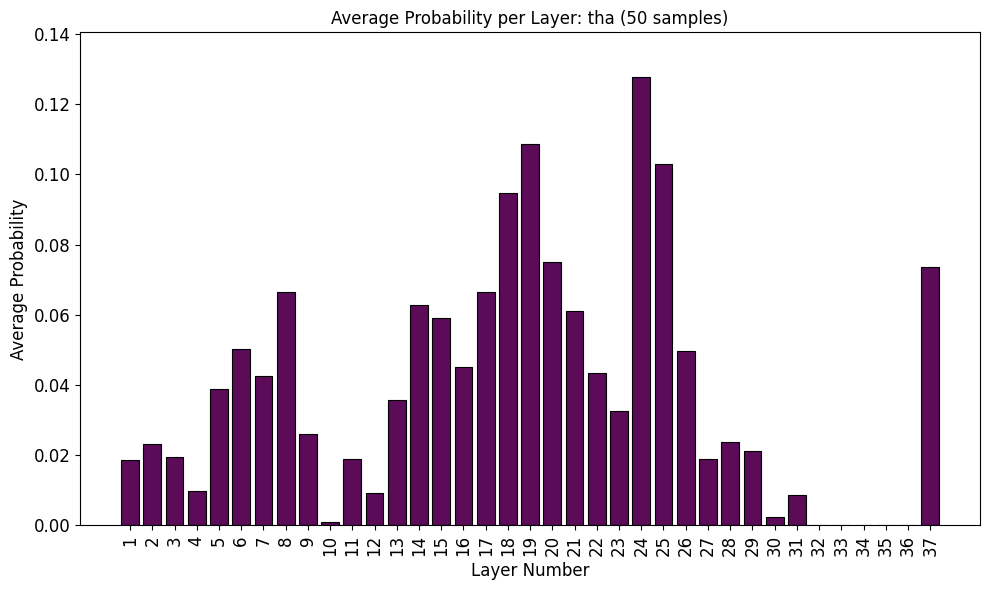

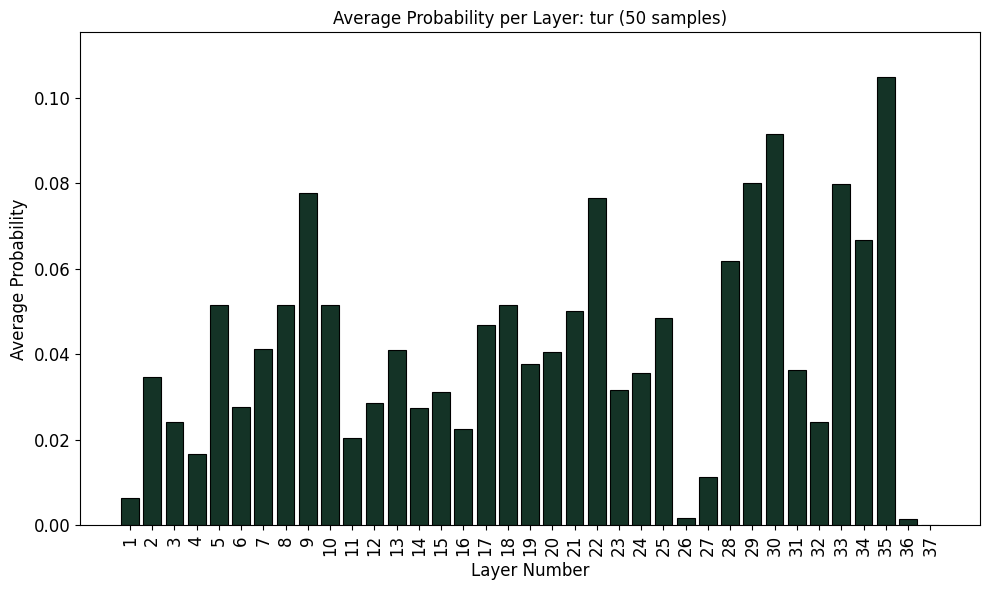

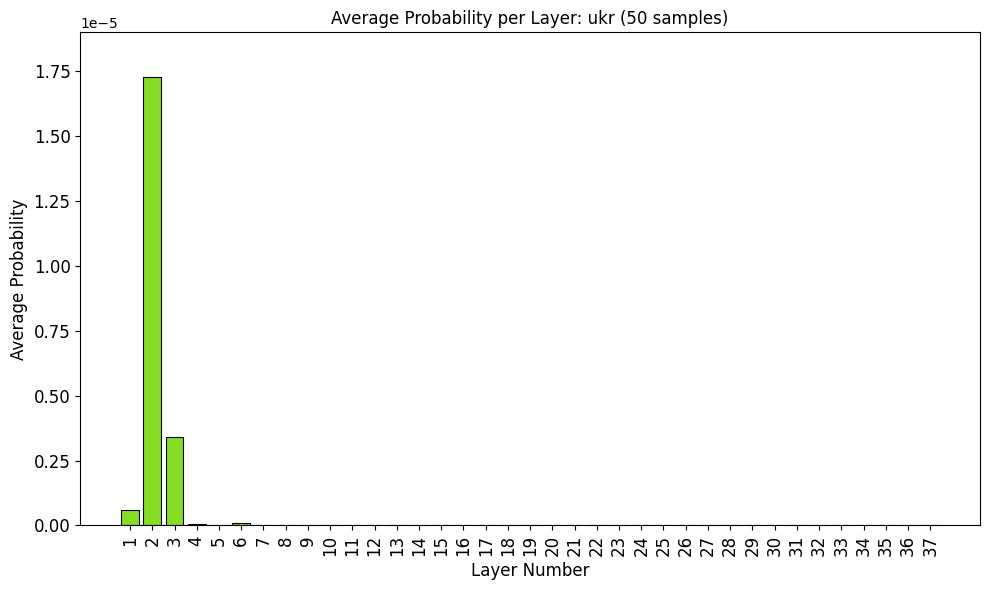

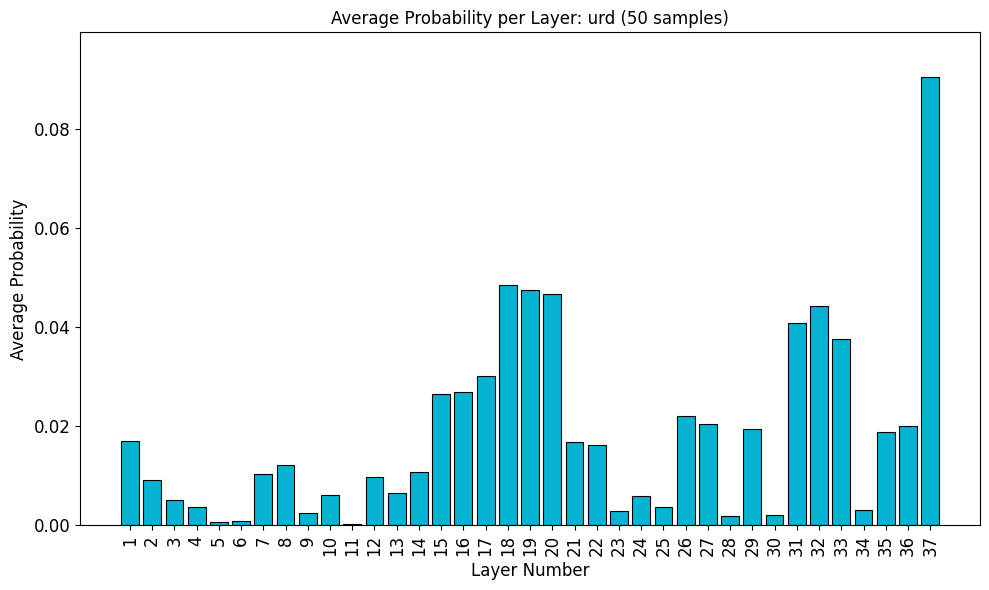

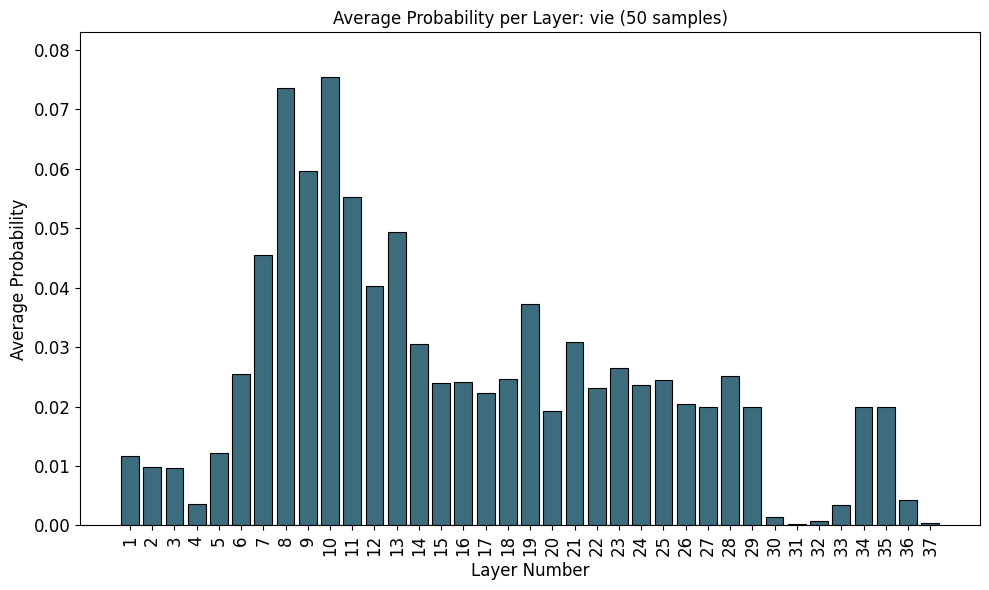

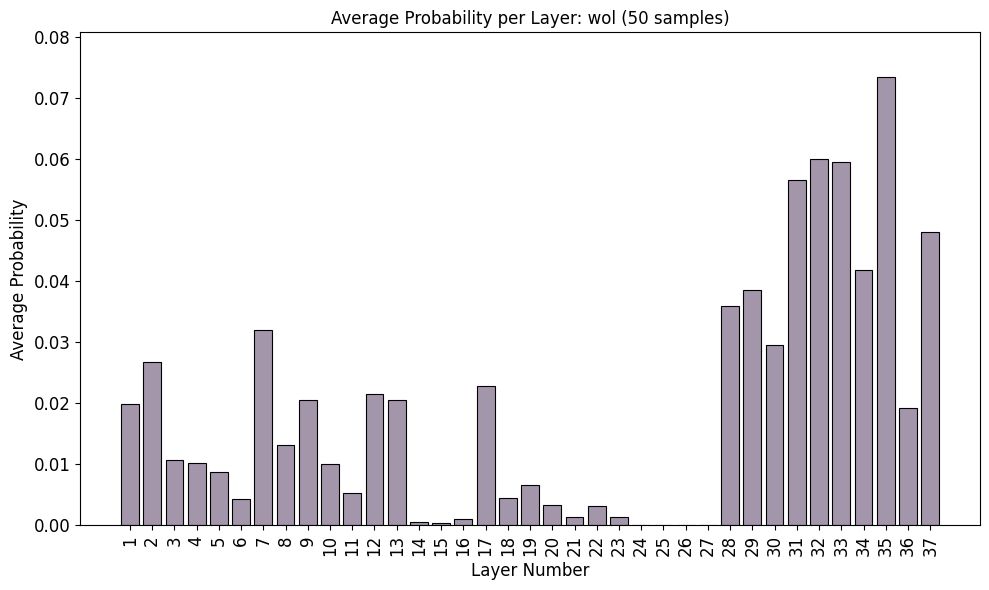

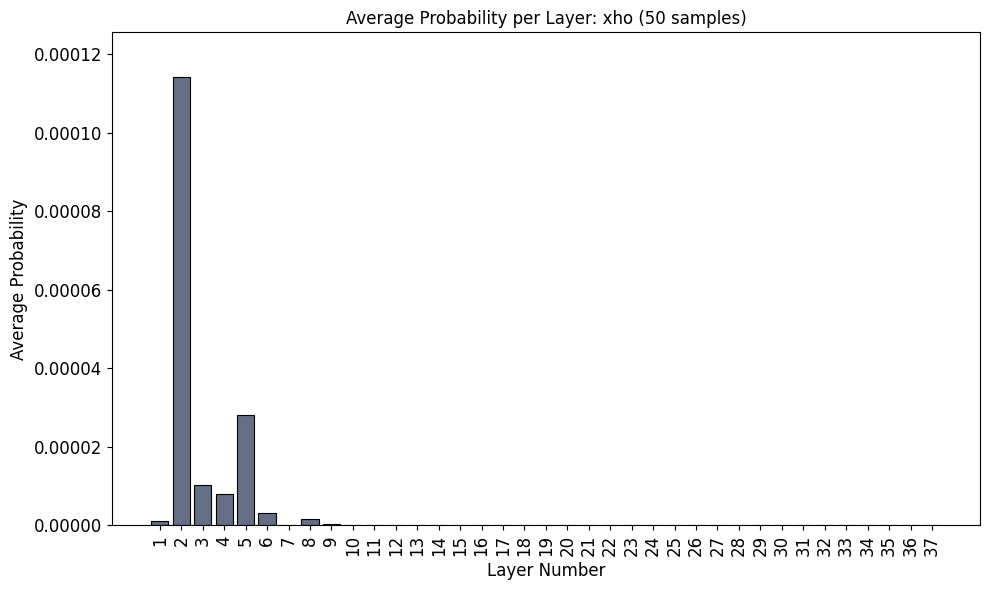

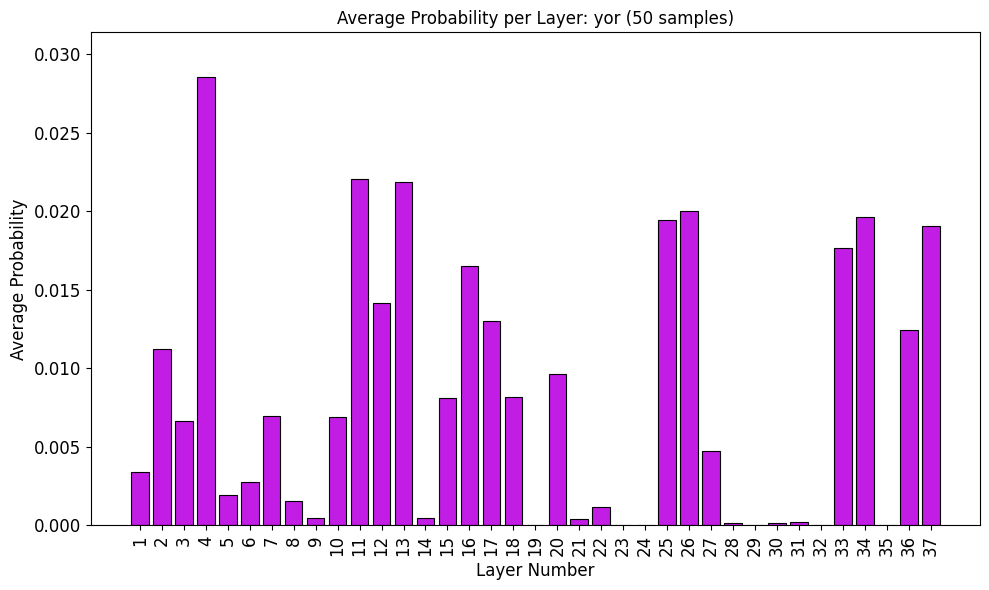

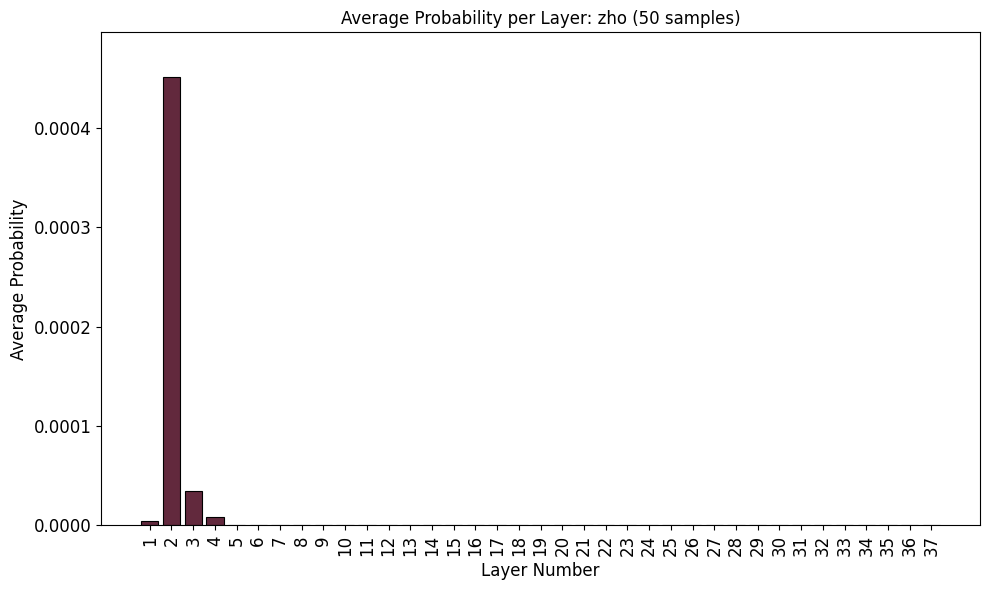

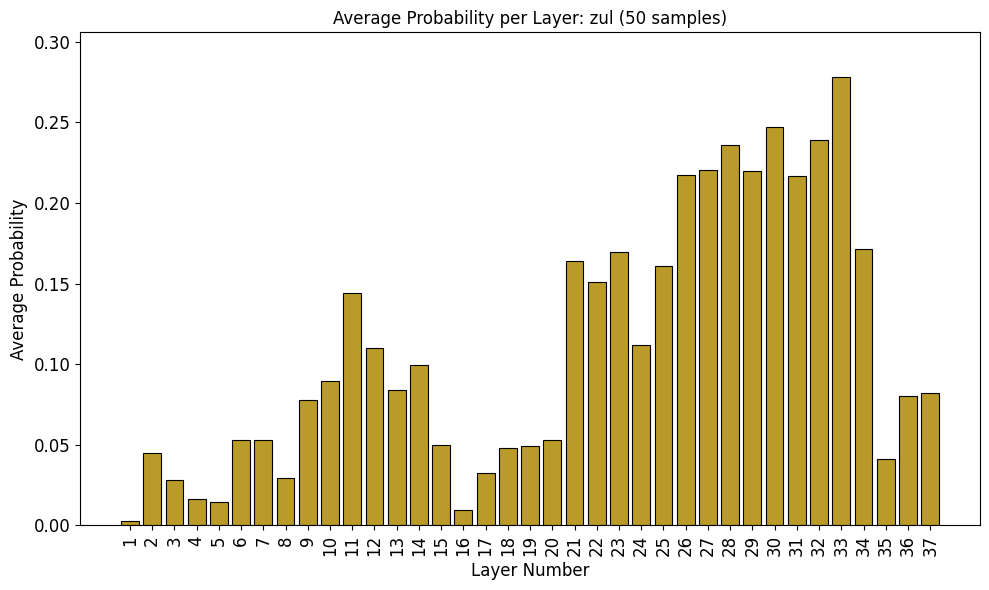

Generated 67 plots in the 'lang_plots' folder.


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import random
import os
FONT_SIZE = 12
os.makedirs('lang_plots', exist_ok=True)
unique_langs = df['ISO-693-3'].unique()
for lang in unique_langs:
    lang_df = df[df['ISO-693-3'] == lang]
    avg_probs = np.mean(np.stack(lang_df['PROB'].values), axis=0)
    layers = np.arange(1, len(avg_probs) + 1)
    RANDOM_COLOR = f"#{random.randint(0, 0xFFFFFF):06x}"
    plt.figure(figsize=(10, 6))
    plt.bar(layers, avg_probs, color=RANDOM_COLOR, edgecolor='black', linewidth=0.8)
    plt.xlabel('Layer Number', fontsize=FONT_SIZE)
    plt.ylabel('Average Probability', fontsize=FONT_SIZE)
    plt.title(f'Average Probability per Layer: {lang} ({len(lang_df)} samples)', fontsize=FONT_SIZE)
    plt.xticks(layers, fontsize=FONT_SIZE, rotation=90)
    plt.yticks(fontsize=FONT_SIZE)
    plt.ylim(0, max(avg_probs) * 1.1)
    plt.tight_layout()
    plt.savefig(f'lang_plots/layer_avg_{lang}.png')
    plt.show()
    plt.close()
print(f"Generated {len(unique_langs)} plots in the 'lang_plots' folder.")

In [15]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
last_layer_key = sorted(df['MAX'].iloc[0].keys())[-1]
y_true = df['ISO-693-3'].tolist()
y_pred = [df['MAX'].iloc[i][last_layer_key]['label'] for i in range(len(df))]
overall_acc = accuracy_score(y_true, y_pred)
overall_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Overall Accuracy: {overall_acc:.4f}")
print(f"Overall Macro F1: {overall_f1:.4f}")
unique_langs = sorted(df['ISO-693-3'].unique())
for lang in unique_langs:
    lang_indices = [i for i, x in enumerate(y_true) if x == lang]
    lang_true = [y_true[i] for i in lang_indices]
    lang_pred = [y_pred[i] for i in lang_indices]
    lang_acc = accuracy_score(lang_true, lang_pred)
    print(f"Language: {lang} | Accuracy: {lang_acc:.4f}")

Overall Accuracy: 0.0272
Overall Macro F1: 0.0186
Language: amh | Accuracy: 0.4800
Language: ara | Accuracy: 0.0200
Language: ben | Accuracy: 0.0000
Language: bul | Accuracy: 0.0000
Language: cat | Accuracy: 0.0200
Language: ces | Accuracy: 0.0000
Language: cym | Accuracy: 0.0000
Language: dan | Accuracy: 0.0600
Language: deu | Accuracy: 0.0000
Language: ell | Accuracy: 0.0000
Language: eng | Accuracy: 0.0000
Language: est | Accuracy: 0.1400
Language: eus | Accuracy: 0.0000
Language: fas | Accuracy: 0.0000
Language: fin | Accuracy: 0.0000
Language: fra | Accuracy: 0.0000
Language: gle | Accuracy: 0.0000
Language: glg | Accuracy: 0.0000
Language: guj | Accuracy: 0.0000
Language: hau | Accuracy: 0.0000
Language: heb | Accuracy: 0.0200
Language: hin | Accuracy: 0.0200
Language: hrv | Accuracy: 0.0000
Language: hun | Accuracy: 0.0200
Language: ibo | Accuracy: 0.0800
Language: ind | Accuracy: 0.0400
Language: ita | Accuracy: 0.0600
Language: jav | Accuracy: 0.0000
Language: jpn | Accuracy: 